In [92]:
import pandas as pd
import numpy as np

In [93]:
df_train = pd.read_pickle('songs_train_preprocessed.pkl')
df_test = pd.read_pickle('songs_test_preprocessed.pkl')
print('train shape:', df_train.shape)
print('test shape:', df_test.shape)

train shape: (7303, 8)
test shape: (808, 8)


In [94]:
df_train.head()

,title,artist,year,views,url,lyric,lyric_proccessed,tokens
0,Untitled,Rex Orange County,2017,292064,https://genius.com/Rex-Orange-County-Untitled-...,So if for any reason there's some miscommunica...,so if for any reason there is some miscommunic...,"[reason, miscommunication, lying, face, immatu..."
1,Dandelions,Ruth B.,2017,587288,https://genius.com/Ruth-B-Dandelions-lyrics,Maybe it's the way you say my name\nMaybe it's...,maybe it is the way you say my name\nmaybe it ...,"[maybe, way, say, name, maybe, way, play, game..."
2,I Like,G Herbo,2017,204698,https://genius.com/G-Herbo-I-Like-lyrics,"Pull up in a new G-Wag'\nSky blue body paint, ...",pull up in a new gwag\nsky blue body paint soo...,"[pull, new, gwag, sky, blue, body, paint, soow..."
3,Kiss Me,Ed Sheeran,2011,434377,https://genius.com/Ed-Sheeran-Kiss-Me-lyrics,"Yeah, I've been feelin' everything\nFrom hate ...",yeah i have been feelin everything\nfrom hate ...,"[yeah, feelin, everything, hate, love, love, l..."
4,I Say A Little Prayer,Aretha Franklin,1968,401893,https://genius.com/Aretha-Franklin-I-Say-A-Lit...,(I say a little prayer for you)\nThe moment I ...,i say a little prayer for you\nthe moment i wa...,"[say, little, prayer, moment, wake, put, makeu..."


In [95]:
df_test.head()

,title,artist,year,views,url,lyric,lyric_proccessed,tokens
0,BTS - Your eyes tell English Translation,Genius English Translations,2020,574010,https://genius.com/Genius-English-Translations...,"[Verse 1: Jung Kook,\nV\n]\nWhy are my eyes fi...",verse jung kook\nv\n\nwhy are my eyes filled ...,"[verse, jung, kook, eye, filled, tear, hey, st..."
1,Superman,Eminem,2002,4716120,https://genius.com/Eminem-Superman-lyrics,Dina Rae\nThey call me Superman\nLeap tall hoe...,dina rae\nthey call me superman\nleap tall hoe...,"[dina, rae, call, superman, leap, tall, hoe, s..."
2,Pussy Money Weed,Lil Wayne,2007,392937,https://genius.com/Lil-Wayne-Pussy-Money-Weed-...,"Oh, yes, I love her, like Egyptian\nShe's ""Poi...",oh yes i love her like egyptian\nshe is poison...,"[yes, love, like, egyptian, poison, michael, b..."
3,Therefore I Am,Billie Eilish,2020,1712636,https://genius.com/Billie-Eilish-Therefore-I-A...,"I'm not your friend\nOr anything, damn\nYou th...",i am not your friend\nor anything damn\nyou th...,"[friend, anything, damn, think, man, think, th..."
4,Renegade,Big Red Machine,2021,404770,https://genius.com/Big-Red-Machine-Renegade-ly...,I tapped on your window on your darkest night\...,i tapped on your window on your darkest night\...,"[tapped, window, darkest, night, really, going..."


Vector Representation

In [96]:
from sentence_transformers import SentenceTransformer

In [97]:
df = df_train.copy()
df = df[['title', 'tokens']]
df.head()

,title,tokens
0,Untitled,"[reason, miscommunication, lying, face, immatu..."
1,Dandelions,"[maybe, way, say, name, maybe, way, play, game..."
2,I Like,"[pull, new, gwag, sky, blue, body, paint, soow..."
3,Kiss Me,"[yeah, feelin, everything, hate, love, love, l..."
4,I Say A Little Prayer,"[say, little, prayer, moment, wake, put, makeu..."


In [98]:
df_test_1 = df_test.copy()

In [99]:
df['lyrics_text'] = df['tokens'].apply(lambda tokens: " ".join(tokens))

In [100]:
df_test_1['lyrics_text'] = df_test['tokens'].apply(lambda tokens: " ".join(tokens))

In [101]:
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df['lyrics_text'].tolist(), convert_to_numpy=True)

In [102]:
embeddings_test = model.encode(df_test_1['lyrics_text'].tolist(), convert_to_numpy=True)

In [103]:
df

,title,tokens,lyrics_text
0,Untitled,"[reason, miscommunication, lying, face, immatu...",reason miscommunication lying face immaturity ...
1,Dandelions,"[maybe, way, say, name, maybe, way, play, game...",maybe way say name maybe way play game good ne...
2,I Like,"[pull, new, gwag, sky, blue, body, paint, soow...",pull new gwag sky blue body paint soowoo insid...
3,Kiss Me,"[yeah, feelin, everything, hate, love, love, l...",yeah feelin everything hate love love lust lus...
4,I Say A Little Prayer,"[say, little, prayer, moment, wake, put, makeu...",say little prayer moment wake put makeup makeu...
...,...,...,...
7361,Ganja Burn,"[ayo, world, turn, blunt, burn, fashion, icon,...",ayo world turn blunt burn fashion icon audrey ...
7362,I Kissed a Girl,"[got, brave, drink, hand, lost, discretion, us...",got brave drink hand lost discretion used want...
7363,One Shot 2 Shot,"[one, shot, two, shot, three, shot, four, shot...",one shot two shot three shot four shot hear gu...
7364,Frontin,"[want, sound, full, rude, looking, dude, love,...",want sound full rude looking dude love sorry b...


# **Clustering**

## **Hierarchical Clustering**: Agglomerative



#### Simple Training

In [104]:
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(n_clusters=11, distance_threshold=None)
df['cluster'] = clustering.fit_predict(embeddings)

In [105]:
df[['title', 'cluster']].head()

,title,cluster
0,Untitled,2
1,Dandelions,1
2,I Like,0
3,Kiss Me,2
4,I Say A Little Prayer,2


In [106]:
df['cluster'].nunique()

11

In [107]:
df['cluster'].value_counts()

cluster
1     1259
5      912
4      837
9      707
0      645
2      578
7      556
3      524
10     493
6      427
8      365
Name: count, dtype: int64

In [108]:
df['cluster'] = df['cluster']
df['cluster'].value_counts()

cluster
1     1259
5      912
4      837
9      707
0      645
2      578
7      556
3      524
10     493
6      427
8      365
Name: count, dtype: int64

In [109]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=50)
embeddings_2d = tsne.fit_transform(embeddings)

df['tsne_x'] = embeddings_2d[:, 0]
df['tsne_y'] = embeddings_2d[:, 1]

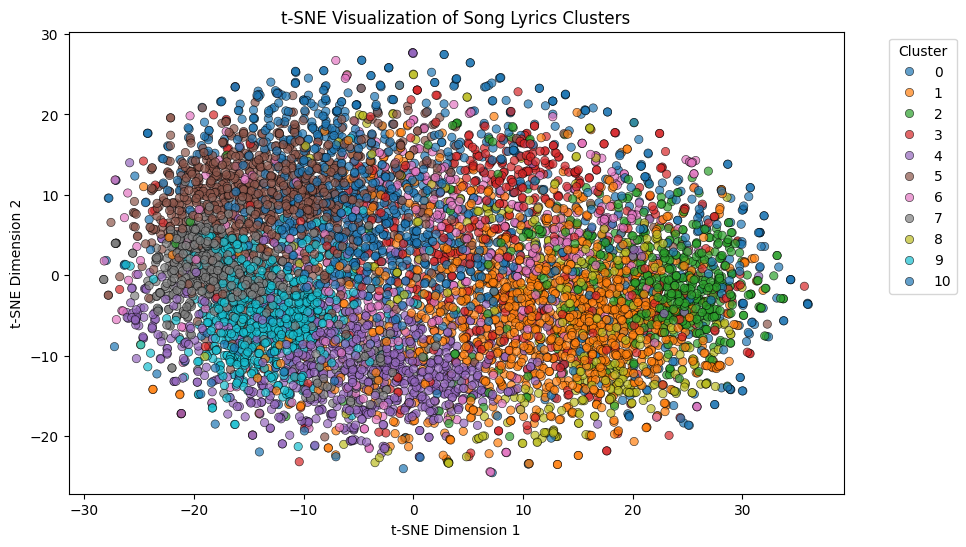

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['tsne_x'], y=df['tsne_y'], hue=df['cluster'], palette='tab10', alpha=0.7, edgecolor='k')
plt.title("t-SNE Visualization of Song Lyrics Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

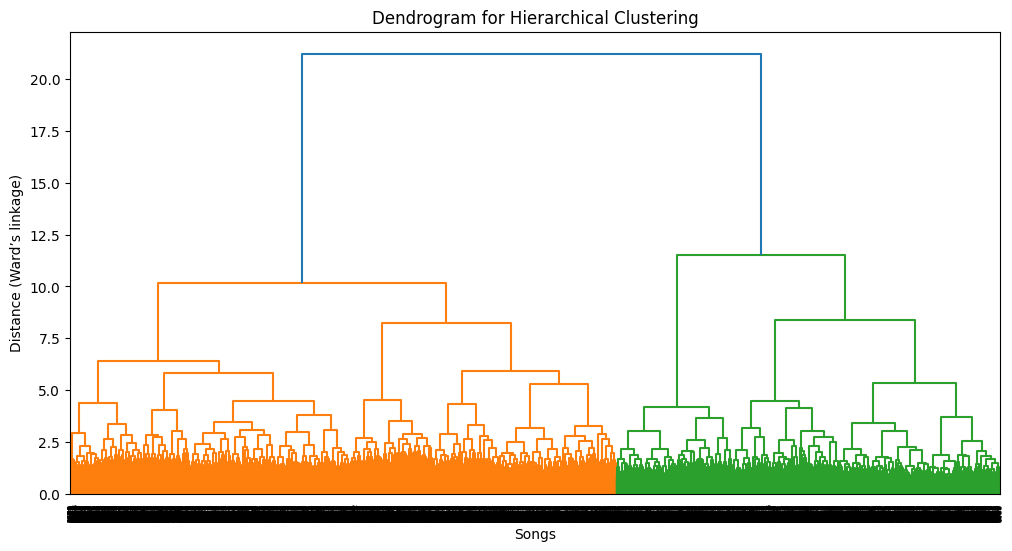

In [111]:
import scipy.cluster.hierarchy as sch

linkage_matrix = sch.linkage(embeddings, method='ward')

plt.figure(figsize=(12, 6))
sch.dendrogram(linkage_matrix, truncate_mode='level', p=20)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Songs")
plt.ylabel("Distance (Ward’s linkage)")
plt.show()

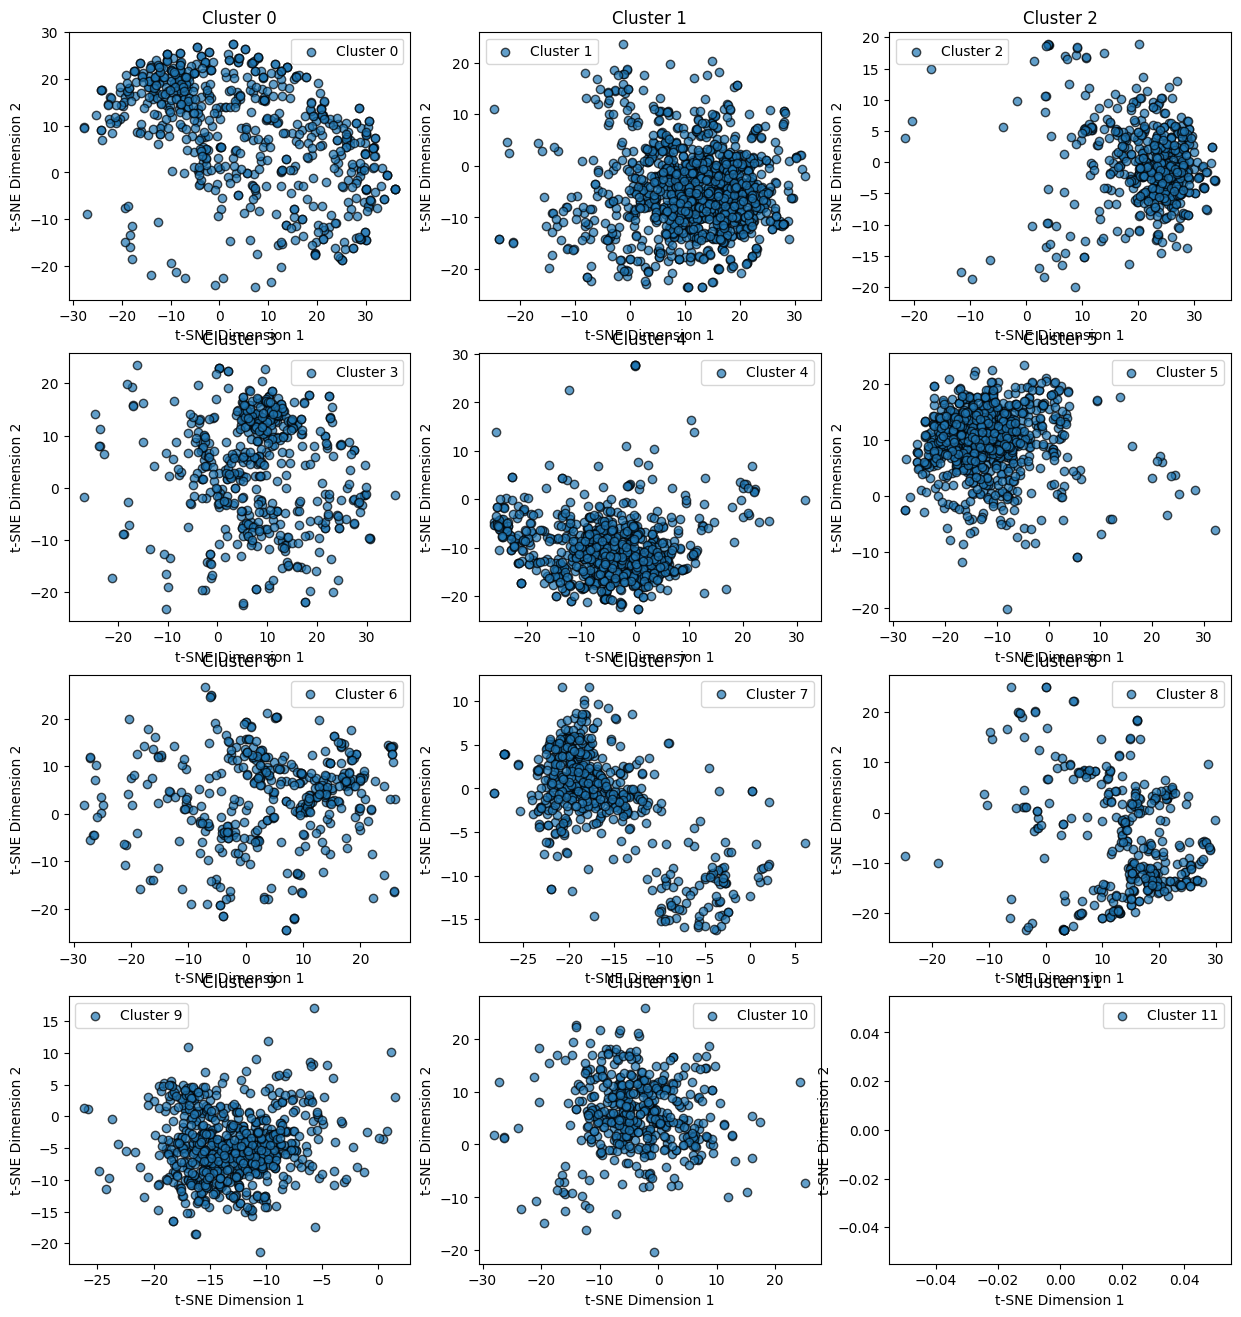

In [112]:
import math
cluster_n = 12
rows = math.ceil(cluster_n / 3)
fig_w = 3 * 5
fig_h = 4 * rows

plt.figure(figsize=(fig_w, fig_h))
for i in range(cluster_n):
    plt.subplot(rows, 3, i + 1)
    cluster_data = df[df['cluster'] == i]

    plt.scatter(cluster_data['tsne_x'], cluster_data['tsne_y'], alpha=0.7, edgecolor='k', label=f"Cluster {i}")
    plt.title(f"Cluster {i}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()

# plt.tight_layout()
plt.show()

#### Hyperparameter Tuning & Metric Analysis

In [113]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

n_clusters_range = [8, 10, 11, 12]
linkage_methods = ['ward', 'complete', 'average']

results = []

for linkage in linkage_methods:
    for n_clusters in n_clusters_range:
        if linkage == 'ward':
            metric = 'euclidean'
        else:
            metric = 'cosine'

        clustering = AgglomerativeClustering(
            n_clusters=n_clusters,
            linkage=linkage,
            metric=metric
        )
        labels = clustering.fit_predict(embeddings)

        try:
            sil = silhouette_score(embeddings, labels, metric=metric)
            db = davies_bouldin_score(embeddings, labels)
            ch = calinski_harabasz_score(embeddings, labels)

            results.append({
                'n_clusters': n_clusters,
                'linkage': linkage,
                'affinity': metric,
                'Silhouette Score': sil,
                'Davies-Bouldin Score': db,
                'Calinski-Harabasz Score': ch
            })
        except Exception as e:
            print(f"Error for {linkage} linkage with {n_clusters} clusters: {e}")

metrics_agglo = pd.DataFrame(results)
metrics_agglo = metrics_agglo.sort_values(by='Silhouette Score', ascending=False)
metrics_agglo.reset_index(drop=True, inplace=True)


In [114]:
metrics_agglo

,n_clusters,linkage,affinity,Silhouette Score,Davies-Bouldin Score,Calinski-Harabasz Score
0,8,average,cosine,0.291709,1.673035,3.720212
1,10,average,cosine,0.279446,1.460983,3.272989
2,11,average,cosine,0.271672,1.565410,3.439090
3,12,average,cosine,0.264342,1.599043,3.388822
4,8,complete,cosine,0.083849,7.054289,58.441803
5,10,complete,cosine,0.079864,6.698258,48.460605
6,12,complete,cosine,0.036270,6.544809,45.337058
7,11,complete,cosine,0.035863,6.847893,49.146153
8,8,ward,euclidean,-0.006801,6.337418,116.835153
9,12,ward,euclidean,-0.024123,6.346039,84.588877


#### Training on selected parameter

In [115]:
clustering = AgglomerativeClustering(
    n_clusters=11,
    linkage='complete',
    metric='cosine',
    distance_threshold=None
)

labels_agglo = clustering.fit_predict(embeddings)
df['agglo_cluster'] = labels_agglo + 1

In [116]:
df_train['agglo_cluster'] = labels_agglo + 1

In [117]:
df['agglo_cluster']

0       11
1        9
2       11
3        1
4        9
        ..
7361     4
7362     4
7363     4
7364    11
7365    11
Name: agglo_cluster, Length: 7303, dtype: int64

In [118]:
df['agglo_cluster'].value_counts()

agglo_cluster
11    3625
9     1858
4      716
7      441
10     175
3      171
1      159
8       55
2       39
6       32
5       32
Name: count, dtype: int64

#### Training Visualization

In [119]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=50)
embeddings_2d = tsne.fit_transform(embeddings)

df['tsne_x'] = embeddings_2d[:, 0]
df['tsne_y'] = embeddings_2d[:, 1]

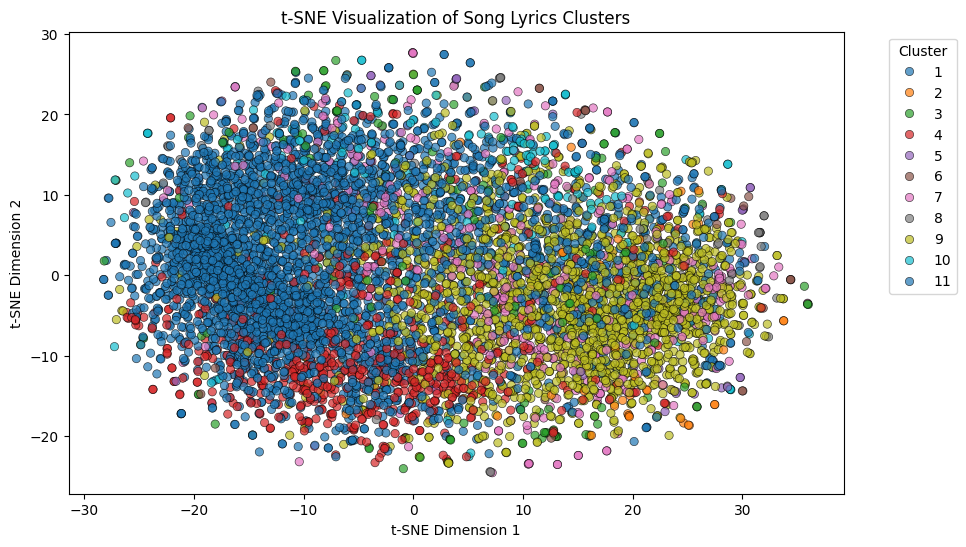

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['tsne_x'], y=df['tsne_y'], hue=df['agglo_cluster'], palette='tab10', alpha=0.7, edgecolor='k')
plt.title("t-SNE Visualization of Song Lyrics Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

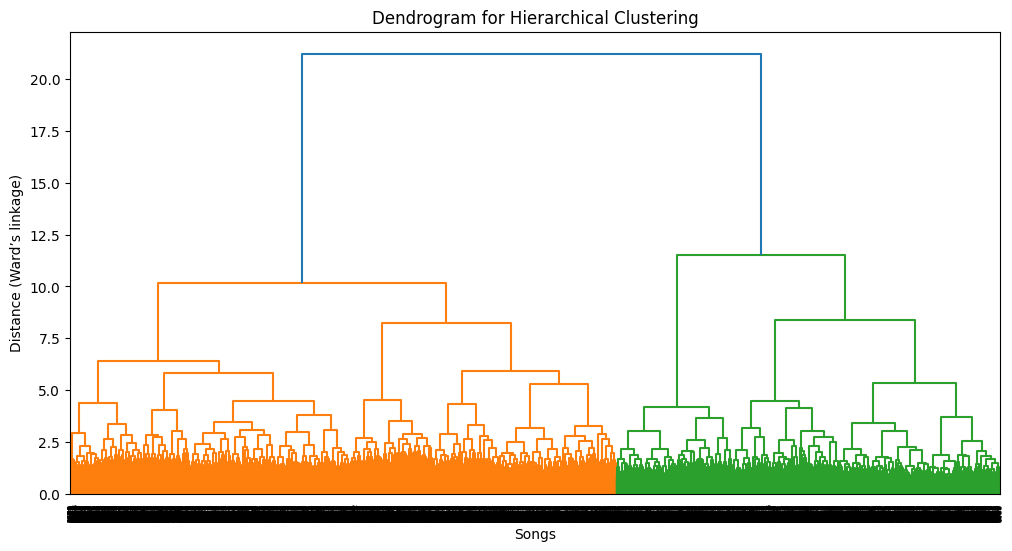

In [121]:
import scipy.cluster.hierarchy as sch

linkage_matrix = sch.linkage(embeddings, method='ward')

plt.figure(figsize=(12, 6))
sch.dendrogram(linkage_matrix, truncate_mode='level', p=20)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Songs")
plt.ylabel("Distance (Ward’s linkage)")
plt.show()

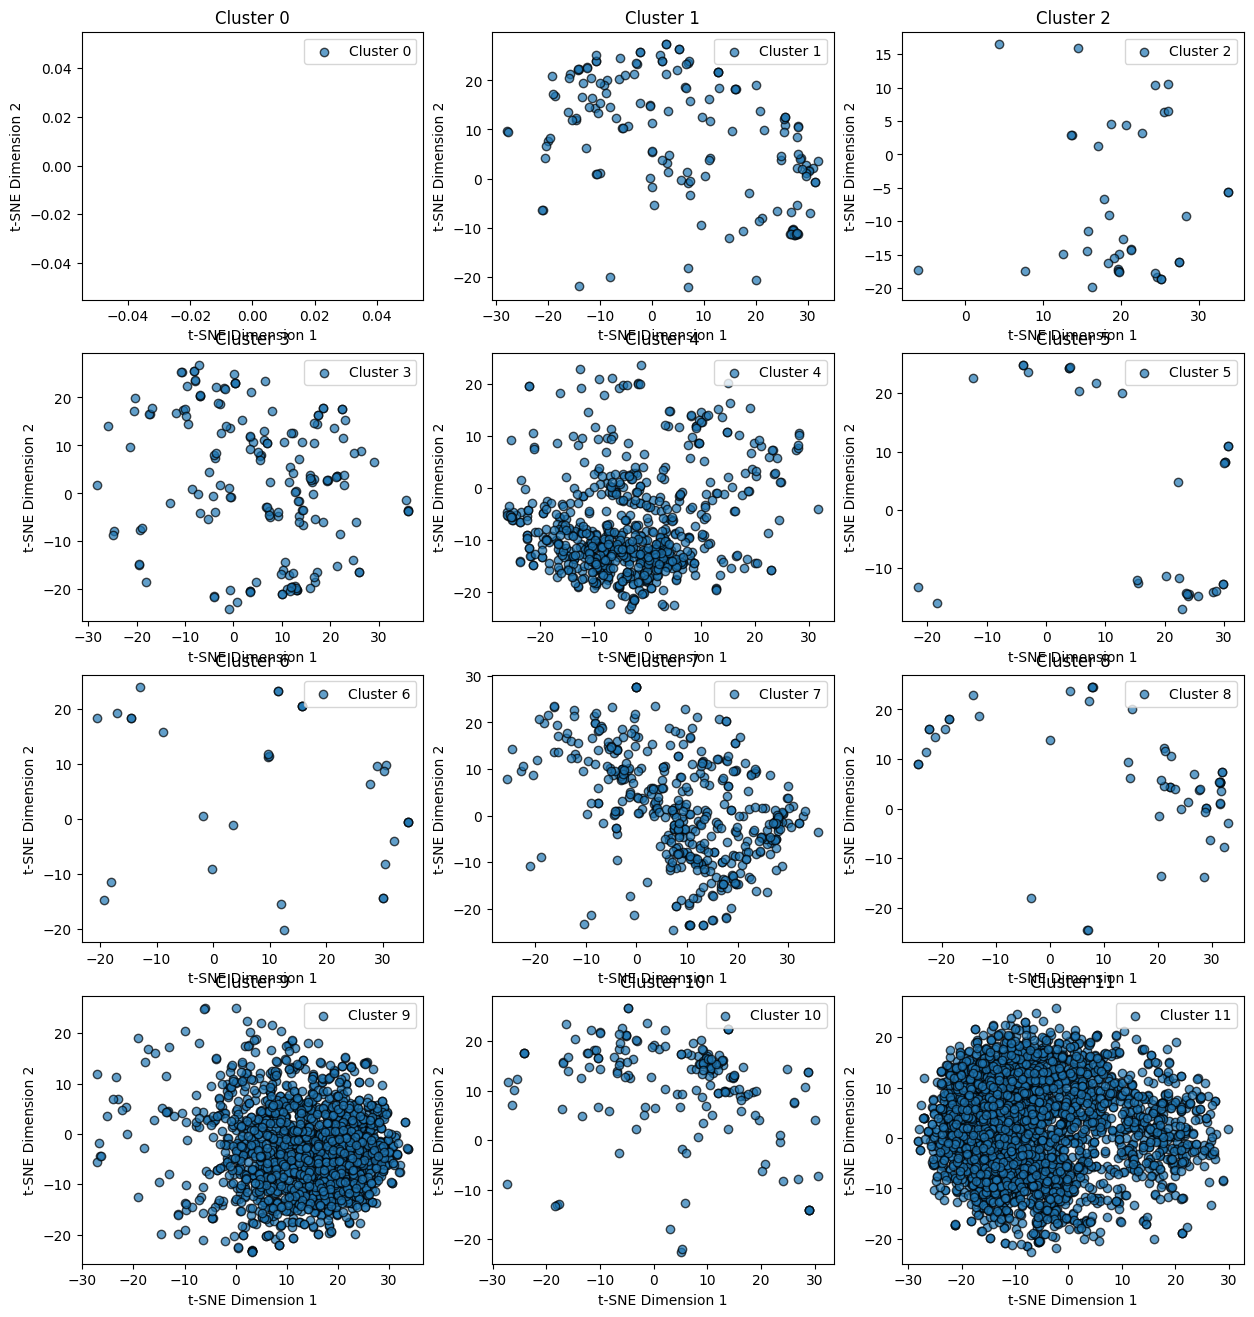

In [122]:
import math
cluster_n = 12
rows = math.ceil(cluster_n / 3)
fig_w = 3 * 5
fig_h = 4 * rows

plt.figure(figsize=(fig_w, fig_h))
for i in range(cluster_n):
    plt.subplot(rows, 3, i + 1)
    cluster_data = df[df['agglo_cluster'] == i]

    plt.scatter(cluster_data['tsne_x'], cluster_data['tsne_y'], alpha=0.7, edgecolor='k', label=f"Cluster {i}")
    plt.title(f"Cluster {i}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()

# plt.tight_layout()
plt.show()

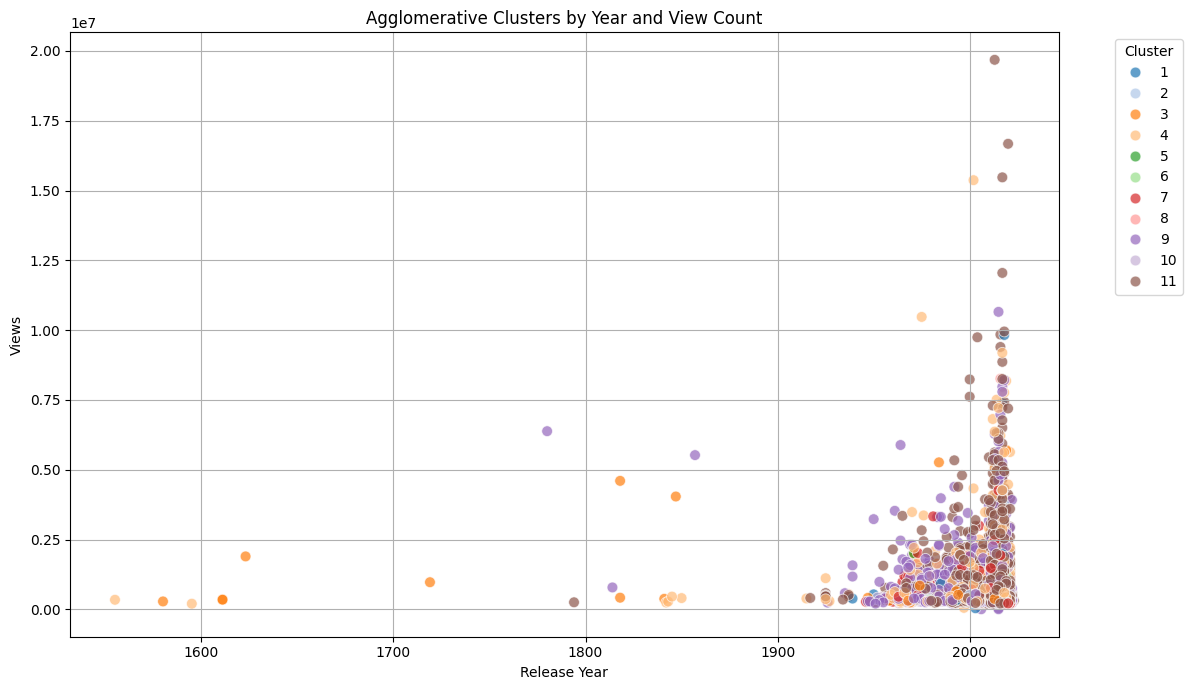

In [123]:
df_filtered = df_train[(df_train['year'] >= 1500) & (~df_train['year'].isna())]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered,
    x='year',
    y='views',
    hue='agglo_cluster',
    palette='tab20',
    alpha=0.7,
    s=60
)
plt.title("Agglomerative Clusters by Year and View Count")
plt.xlabel("Release Year")
plt.ylabel("Views")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Testing Modelling

In [124]:
clustering = AgglomerativeClustering(
    n_clusters=11,
    linkage='complete',
    metric='cosine',
    distance_threshold=None
)

labels_agglo = clustering.fit_predict(embeddings_test)
df_test['agglo_cluster'] = labels_agglo + 1

In [125]:
df_test

,title,artist,year,views,url,lyric,lyric_proccessed,tokens,agglo_cluster
0,BTS - Your eyes tell English Translation,Genius English Translations,2020,574010,https://genius.com/Genius-English-Translations...,"[Verse 1: Jung Kook,\nV\n]\nWhy are my eyes fi...",verse jung kook\nv\n\nwhy are my eyes filled ...,"[verse, jung, kook, eye, filled, tear, hey, st...",1
1,Superman,Eminem,2002,4716120,https://genius.com/Eminem-Superman-lyrics,Dina Rae\nThey call me Superman\nLeap tall hoe...,dina rae\nthey call me superman\nleap tall hoe...,"[dina, rae, call, superman, leap, tall, hoe, s...",1
2,Pussy Money Weed,Lil Wayne,2007,392937,https://genius.com/Lil-Wayne-Pussy-Money-Weed-...,"Oh, yes, I love her, like Egyptian\nShe's ""Poi...",oh yes i love her like egyptian\nshe is poison...,"[yes, love, like, egyptian, poison, michael, b...",1
3,Therefore I Am,Billie Eilish,2020,1712636,https://genius.com/Billie-Eilish-Therefore-I-A...,"I'm not your friend\nOr anything, damn\nYou th...",i am not your friend\nor anything damn\nyou th...,"[friend, anything, damn, think, man, think, th...",1
4,Renegade,Big Red Machine,2021,404770,https://genius.com/Big-Red-Machine-Renegade-ly...,I tapped on your window on your darkest night\...,i tapped on your window on your darkest night\...,"[tapped, window, darkest, night, really, going...",7
...,...,...,...,...,...,...,...,...,...
806,BTS - Outro: Tear English Translation,Genius English Translations,2018,712245,https://genius.com/Genius-English-Translations...,My heart that's stained with belated self-loat...,my heart that is stained with belated selfloat...,"[heart, stained, belated, selfloathing, someon...",1
807,Every Season,Roddy Ricch,2018,592105,https://genius.com/Roddy-Ricch-Every-Season-ly...,"Beezo need cash only, you dig?\nThat boy Cassi...",beezo need cash only you dig\nthat boy cassius...,"[beezo, need, cash, dig, boy, cassius, married...",1
808,Papercut,Linkin Park,2001,288929,https://genius.com/Linkin-Park-Papercut-lyrics,Why does it feel like night today?\nSomething ...,why does it feel like night today\nsomething i...,"[feel, like, night, today, something, right, t...",1
809,Gas Pedal,Sage The Gemini,2013,573690,https://genius.com/Sage-The-Gemini-Gas-Pedal-l...,"Now speed up, gas pedal\nGas pedal (Gas pedal)...",now speed up gas pedal\ngas pedal gas pedal ga...,"[speed, gas, pedal, gas, pedal, gas, pedal, ga...",8


In [126]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=50)
embeddings_2d = tsne.fit_transform(embeddings_test)

df_test['tsne_x'] = embeddings_2d[:, 0]
df_test['tsne_y'] = embeddings_2d[:, 1]

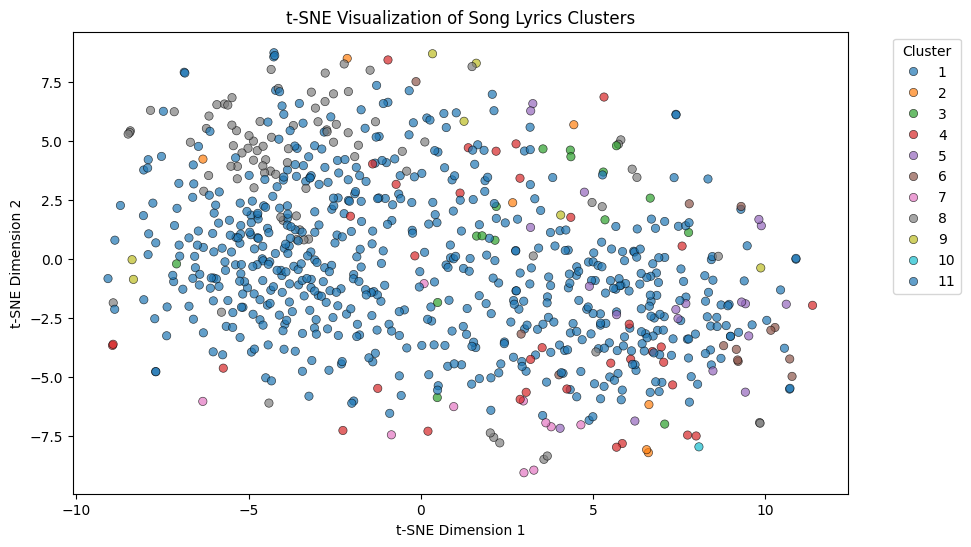

In [127]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_test['tsne_x'], y=df_test['tsne_y'], hue=df_test['agglo_cluster'], palette='tab10', alpha=0.7, edgecolor='k')
plt.title("t-SNE Visualization of Song Lyrics Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

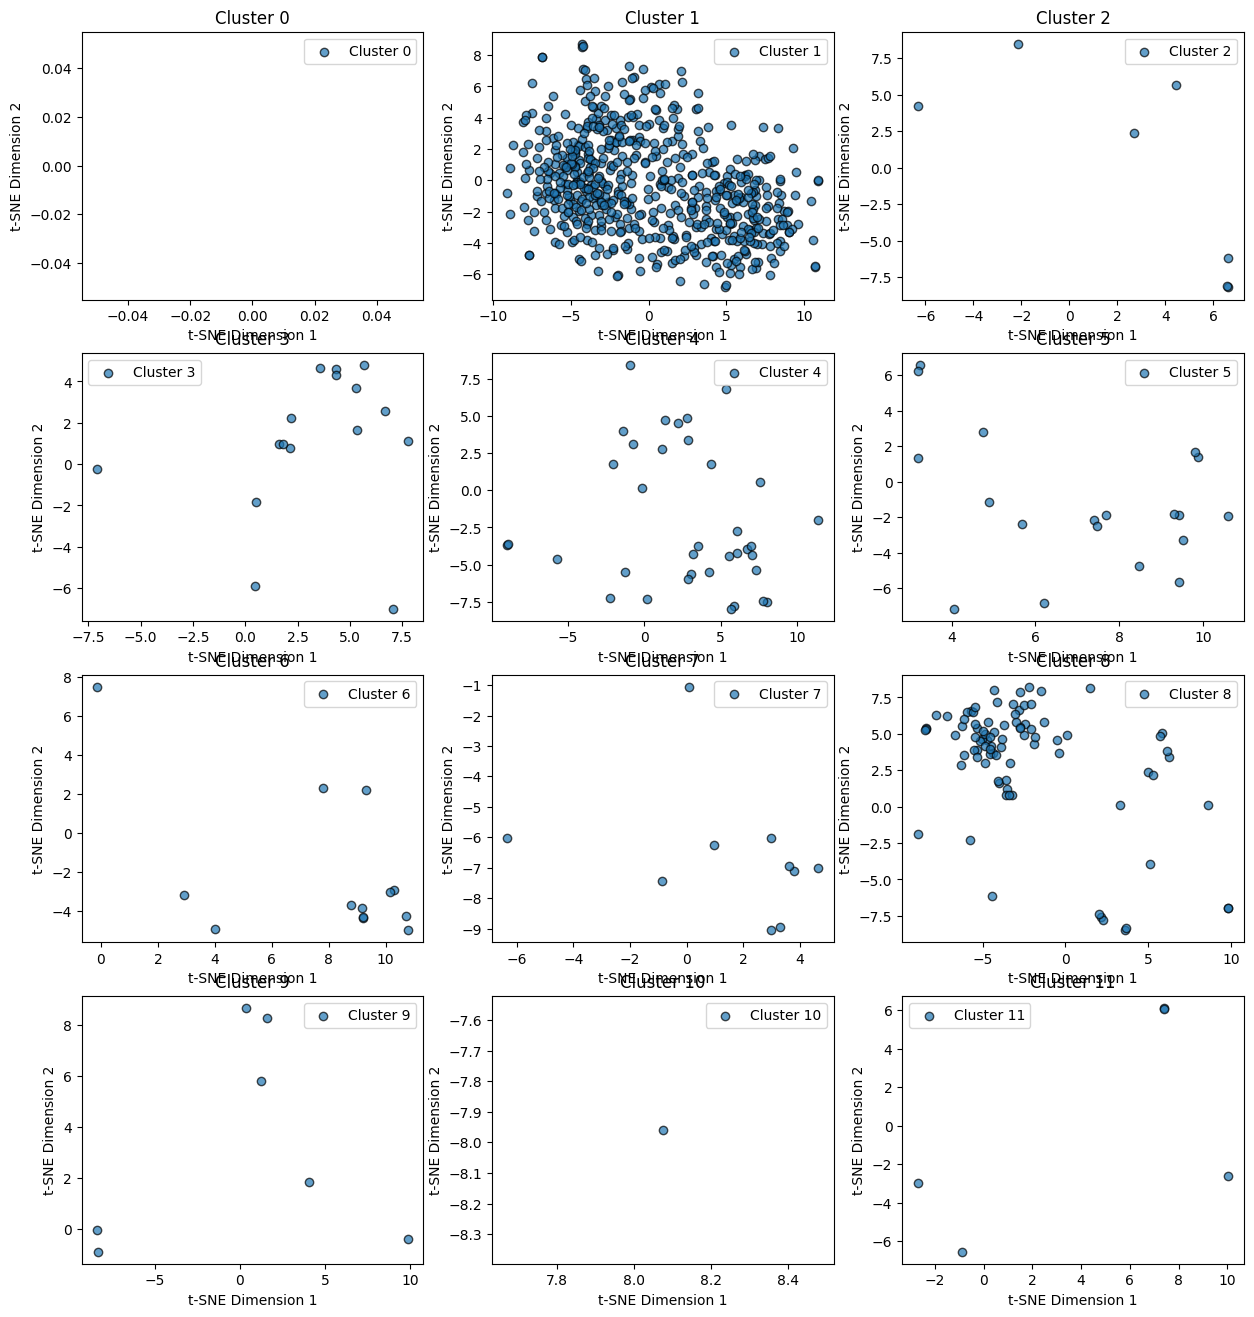

In [128]:
import math
cluster_n = 12
rows = math.ceil(cluster_n / 3)
fig_w = 3 * 5
fig_h = 4 * rows

plt.figure(figsize=(fig_w, fig_h))
for i in range(cluster_n):
    plt.subplot(rows, 3, i + 1)
    cluster_data = df_test[df_test['agglo_cluster'] == i]

    plt.scatter(cluster_data['tsne_x'], cluster_data['tsne_y'], alpha=0.7, edgecolor='k', label=f"Cluster {i}")
    plt.title(f"Cluster {i}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()

# plt.tight_layout()
plt.show()

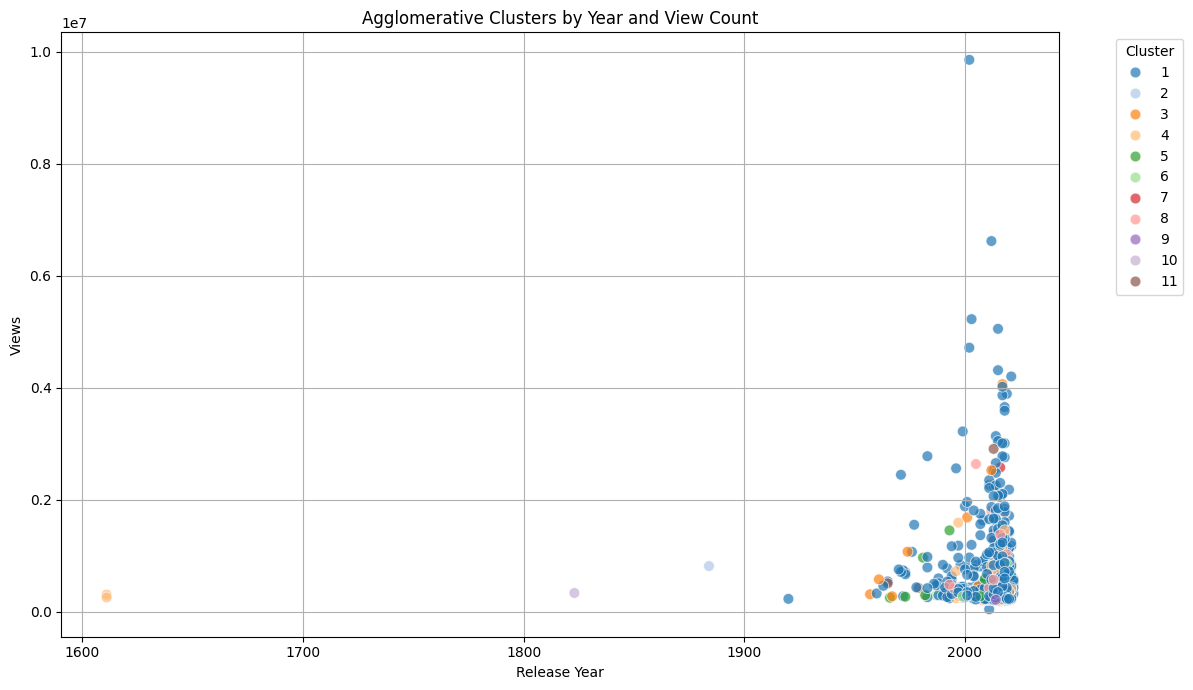

In [129]:
df_filtered = df_test[(df_test['year'] >= 1500) & (~df_test['year'].isna())]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered,
    x='year',
    y='views',
    hue='agglo_cluster',
    palette='tab20',
    alpha=0.7,
    s=60
)
plt.title("Agglomerative Clusters by Year and View Count")
plt.xlabel("Release Year")
plt.ylabel("Views")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## **Partitioned Clustering**: K Means

#### Hyperparameter Tuning & Metric Analysis

K=8, Silhouette Score=-0.0057
K=9, Silhouette Score=-0.0054
K=10, Silhouette Score=-0.0049
K=11, Silhouette Score=-0.0042
K=12, Silhouette Score=-0.0053


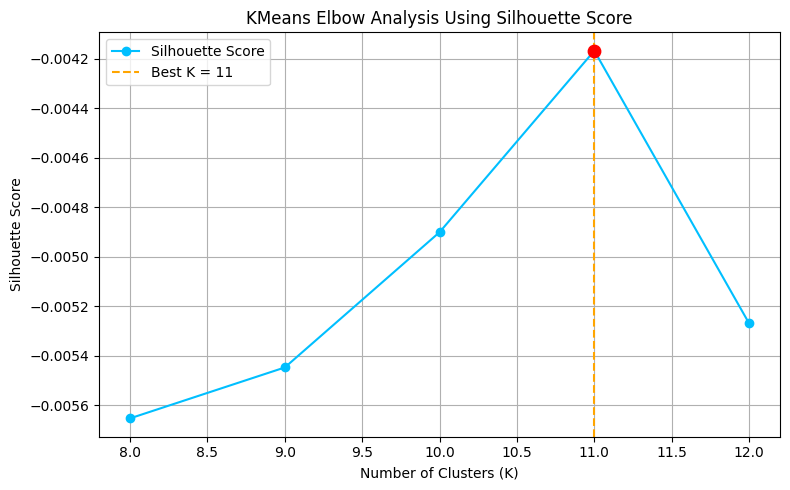

In [130]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(8, 13)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    score = silhouette_score(embeddings, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o", linestyle="-", color="deepskyblue", label='Silhouette Score')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("KMeans Elbow Analysis Using Silhouette Score")
plt.grid(True)

best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
best_score = max(silhouette_scores)
plt.axvline(best_k, color='orange', linestyle='--', label=f'Best K = {best_k}')
plt.scatter(best_k, best_score, color='red', s=80, zorder=5)
plt.legend()
plt.tight_layout()

#### Training on selected parameter

In [131]:
optimal_k = 11
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['kmeans_clustering'] = kmeans.fit_predict(embeddings)

In [132]:
df_train['kmeans_clustering'] = kmeans.fit_predict(embeddings)

#### Training Visualization

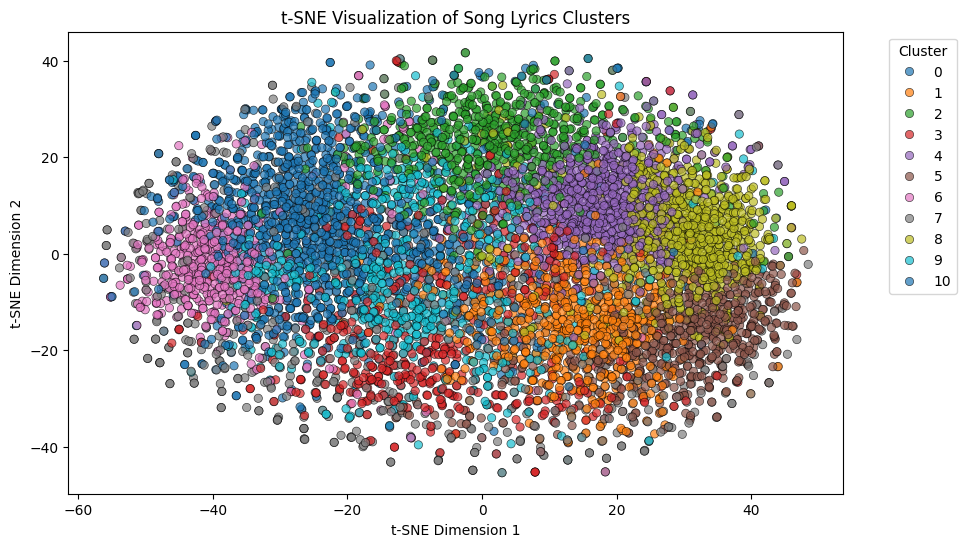

In [133]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings)

df['tsne_x'] = embeddings_2d[:, 0]
df['tsne_y'] = embeddings_2d[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['tsne_x'], y=df['tsne_y'], hue=df['kmeans_clustering'], palette='tab10', alpha=0.7, edgecolor='k')
plt.title("t-SNE Visualization of Song Lyrics Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

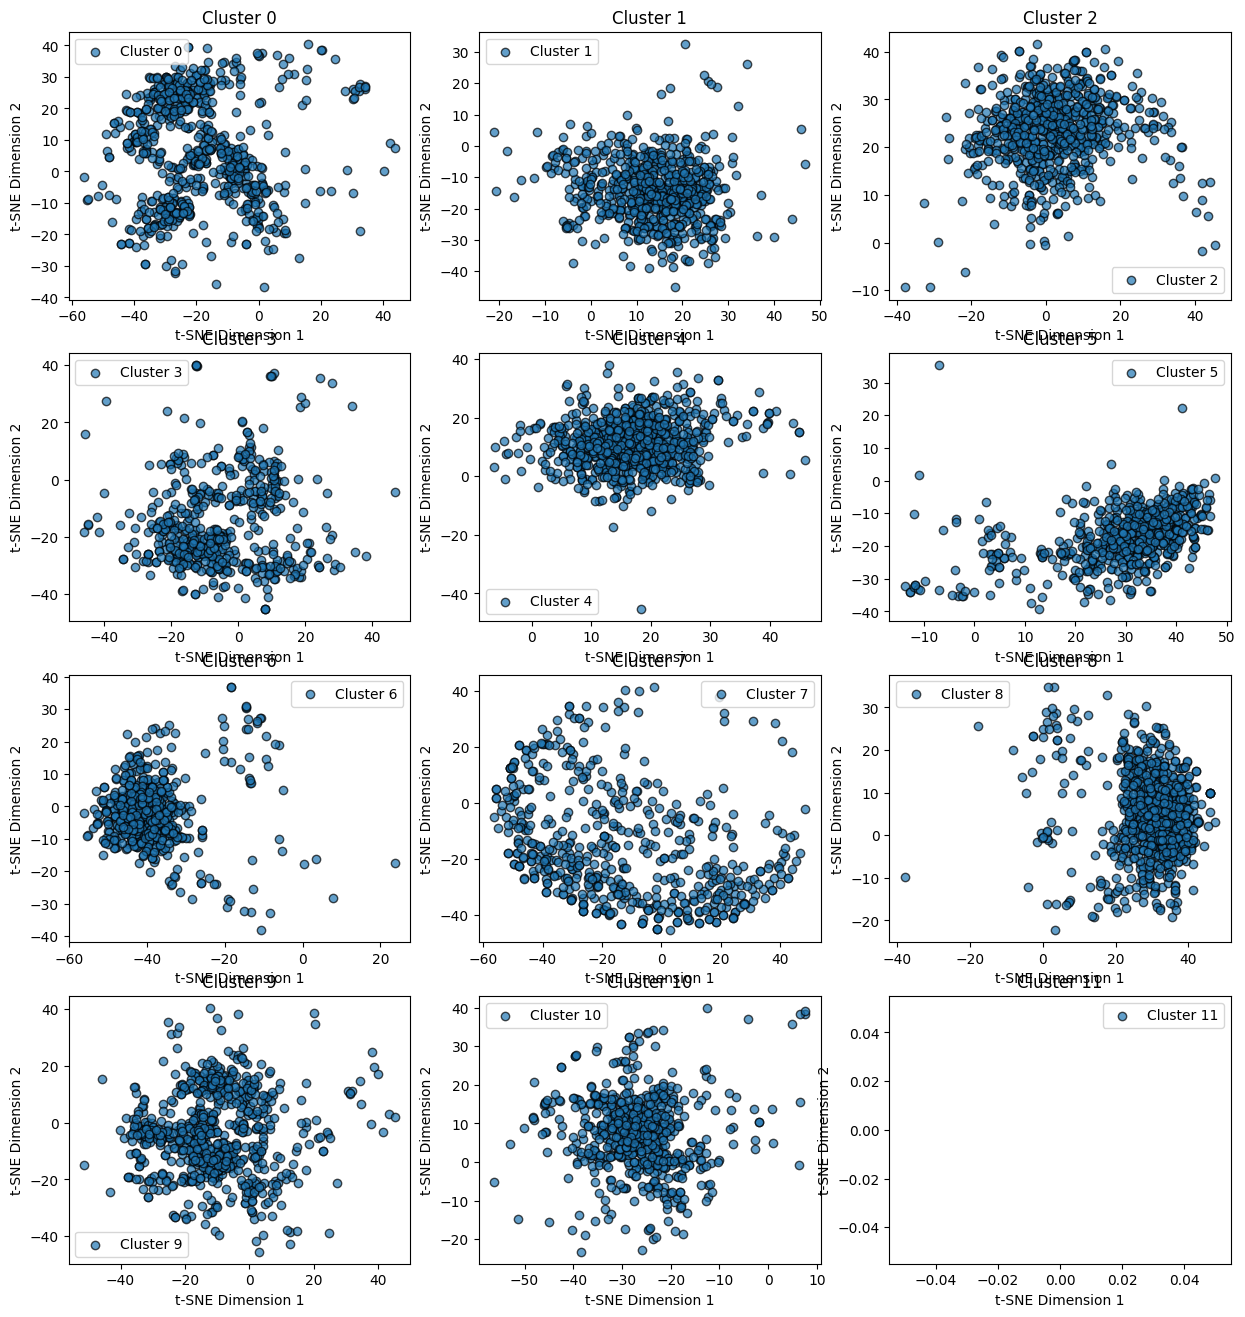

In [134]:
import math
cluster_n = 12
rows = math.ceil(cluster_n / 3)
fig_w = 3 * 5
fig_h = 4 * rows

plt.figure(figsize=(fig_w, fig_h))
for i in range(cluster_n):
    plt.subplot(rows, 3, i + 1)
    cluster_data = df[df['kmeans_clustering'] == i]

    plt.scatter(cluster_data['tsne_x'], cluster_data['tsne_y'], alpha=0.7, edgecolor='k', label=f"Cluster {i}")
    plt.title(f"Cluster {i}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()

# plt.tight_layout()
plt.show()

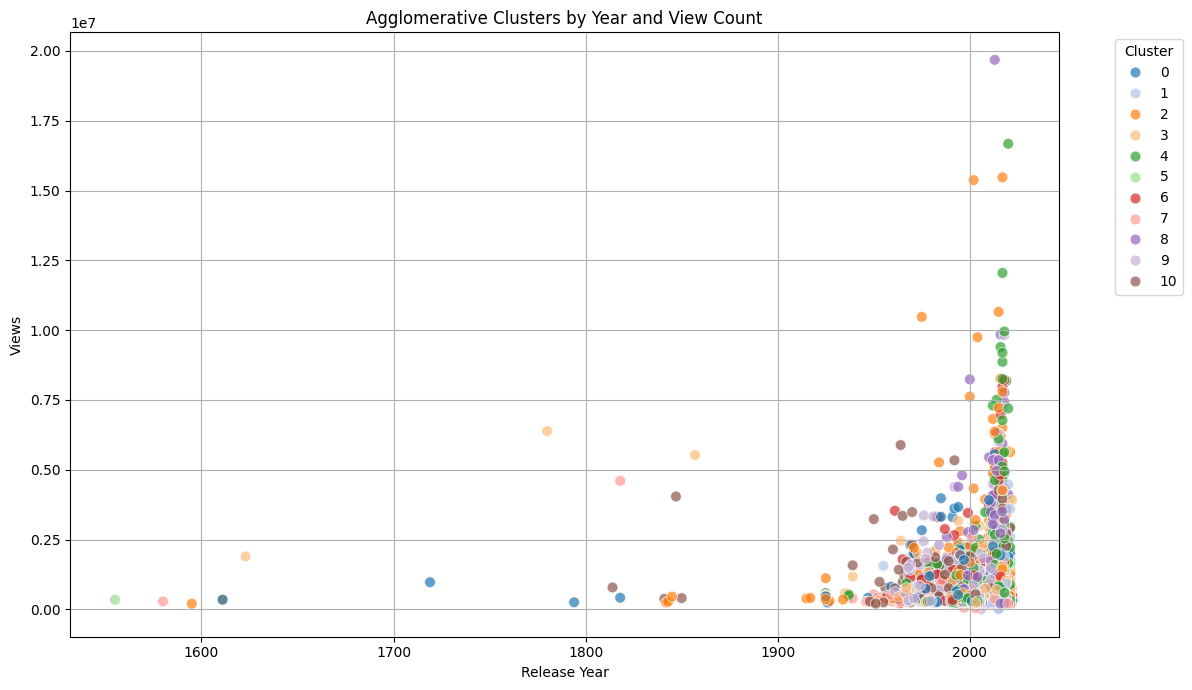

In [135]:
df_filtered = df_train[(df_train['year'] >= 1500) & (~df_train['year'].isna())]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered,
    x='year',
    y='views',
    hue='kmeans_clustering',
    palette='tab20',
    alpha=0.7,
    s=60
)
plt.title("Agglomerative Clusters by Year and View Count")
plt.xlabel("Release Year")
plt.ylabel("Views")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Testing Modelling

In [136]:
df_test['kmeans_clustering'] = kmeans.fit_predict(embeddings_test)

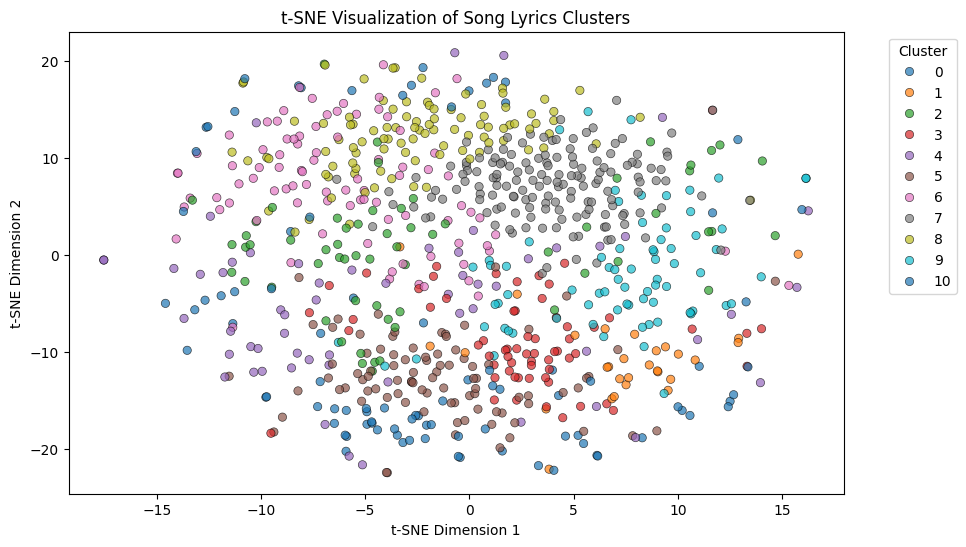

In [137]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings_test)

df_test['tsne_x'] = embeddings_2d[:, 0]
df_test['tsne_y'] = embeddings_2d[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_test['tsne_x'], y=df_test['tsne_y'], hue=df_test['kmeans_clustering'], palette='tab10', alpha=0.7, edgecolor='k')
plt.title("t-SNE Visualization of Song Lyrics Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

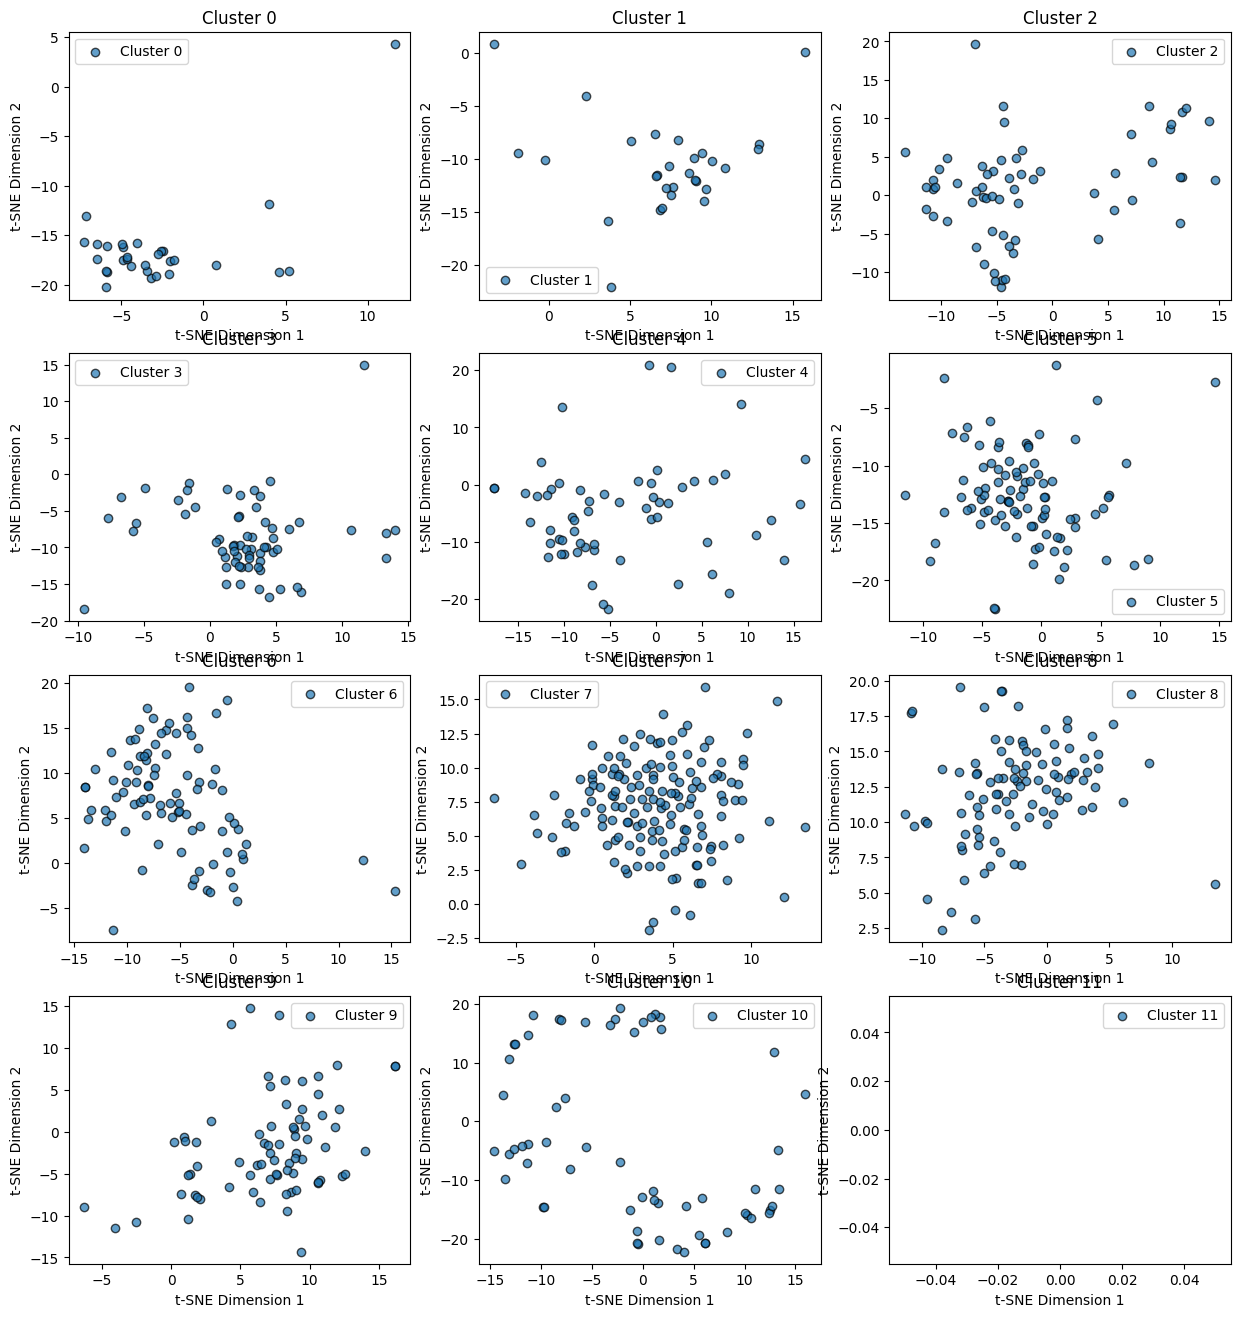

In [138]:
import math
cluster_n = 12
rows = math.ceil(cluster_n / 3)
fig_w = 3 * 5
fig_h = 4 * rows

plt.figure(figsize=(fig_w, fig_h))
for i in range(cluster_n):
    plt.subplot(rows, 3, i + 1)
    cluster_data = df_test[df_test['kmeans_clustering'] == i]

    plt.scatter(cluster_data['tsne_x'], cluster_data['tsne_y'], alpha=0.7, edgecolor='k', label=f"Cluster {i}")
    plt.title(f"Cluster {i}")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()

# plt.tight_layout()
plt.show()

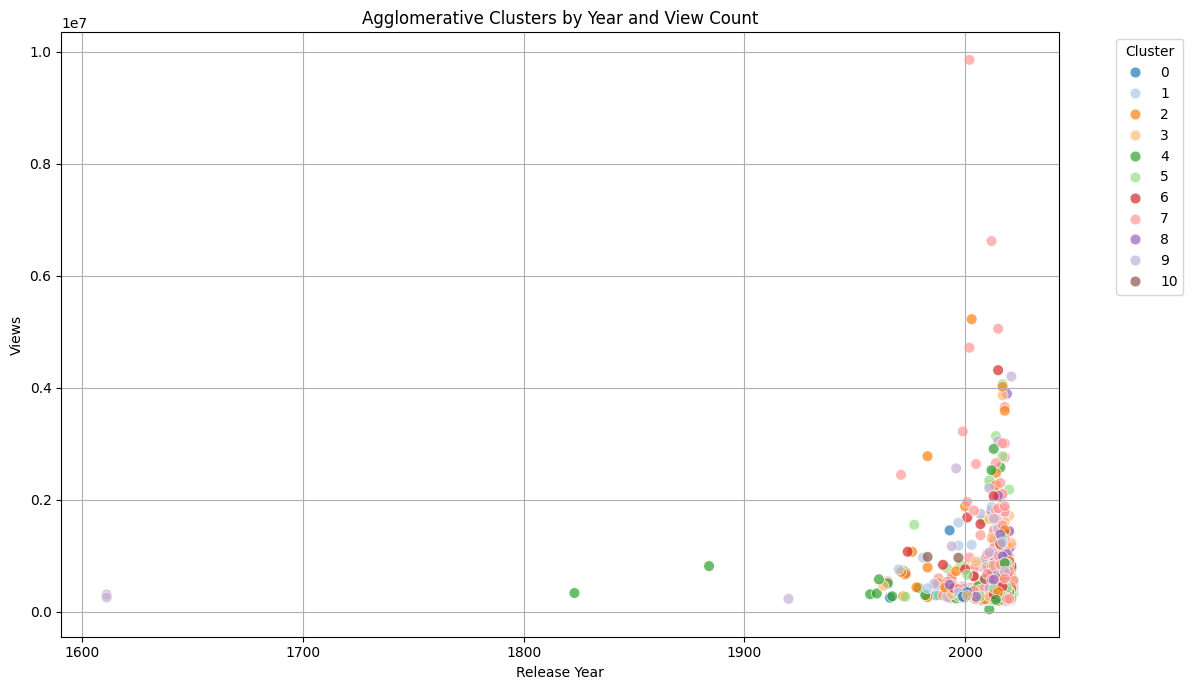

In [139]:
df_filtered = df_test[(df_test['year'] >= 1500) & (~df_test['year'].isna())]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered,
    x='year',
    y='views',
    hue='kmeans_clustering',
    palette='tab20',
    alpha=0.7,
    s=60
)
plt.title("Agglomerative Clusters by Year and View Count")
plt.xlabel("Release Year")
plt.ylabel("Views")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## **Density-based Clustering**: HDBSCAN

In [140]:
embeddings

array([[-0.08094803,  0.05172422,  0.05169685, ...,  0.05624823,
         0.00397791, -0.0213622 ],
       [-0.05183046, -0.02663402,  0.07246941, ...,  0.03668397,
        -0.01186764, -0.07760917],
       [-0.03693973,  0.01610512,  0.09730202, ..., -0.03849169,
         0.02745884, -0.01638548],
       ...,
       [ 0.01010032, -0.09600254, -0.00334168, ...,  0.00337815,
         0.0004288 , -0.05548247],
       [-0.05505428, -0.07757647,  0.04838703, ..., -0.02041806,
        -0.0327851 , -0.06098109],
       [-0.07658569, -0.02997596, -0.01065967, ...,  0.03395789,
        -0.01092348, -0.03918596]], dtype=float32)

#### Simple Training

In [141]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=3, metric='euclidean')
df['hdbscan_cluster'] = clusterer.fit_predict(embeddings)
df.head()

C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,title,tokens,lyrics_text,cluster,tsne_x,tsne_y,agglo_cluster,kmeans_clustering,hdbscan_cluster
0,Untitled,"[reason, miscommunication, lying, face, immatu...",reason miscommunication lying face immaturity ...,2,-48.780376,-5.697989,11,6,-1
1,Dandelions,"[maybe, way, say, name, maybe, way, play, game...",maybe way say name maybe way play game good ne...,1,-35.237293,14.920890,9,10,-1
2,I Like,"[pull, new, gwag, sky, blue, body, paint, soow...",pull new gwag sky blue body paint soowoo insid...,0,20.216837,-30.917900,11,7,-1
3,Kiss Me,"[yeah, feelin, everything, hate, love, love, l...",yeah feelin everything hate love love lust lus...,2,-53.753635,-6.523825,1,6,-1
4,I Say A Little Prayer,"[say, little, prayer, moment, wake, put, makeu...",say little prayer moment wake put makeup makeu...,2,-45.717342,-4.916932,9,6,-1


#### Hyperparameter Tuning on Best Silhoutte Score

In [142]:
from sklearn.metrics.pairwise import cosine_distances
import umap.umap_ as umap

reducer = umap.UMAP(n_components=10, metric='cosine', random_state=42)
reduced_embeddings = reducer.fit_transform(embeddings)
distance_matrix = cosine_distances(reduced_embeddings).astype(np.float64)

C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [143]:
from sklearn.neighbors import NearestNeighbors

param_grid = {
    'min_cluster_size': [15, 17, 20, 22, 25],
    'min_samples': [4, 5, 8, 10, 12, 15, 17]
}

best_config = None
best_score = -1
best_labels = None

for min_cluster_size in param_grid['min_cluster_size']:
    for min_samples in param_grid['min_samples']:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            metric='precomputed',
            cluster_selection_method='leaf'
        )
        raw_labels = clusterer.fit_predict(distance_matrix)

        mask_core = raw_labels != -1
        mask_noise = raw_labels == -1
        labels = raw_labels.copy()

        if np.any(mask_noise):
            nn = NearestNeighbors(n_neighbors=1, metric='cosine')
            nn.fit(reduced_embeddings[mask_core])
            _, indices = nn.kneighbors(reduced_embeddings[mask_noise])
            labels[mask_noise] = raw_labels[mask_core][indices[:, 0]]

        n_clusters = len(set(labels))

        if 12 <= n_clusters <= 18:
            score = silhouette_score(reduced_embeddings, labels, metric='cosine')
            print(f"Clusters: {n_clusters}, Silhouette: {score:.3f}, min_size={min_cluster_size}, min_samples={min_samples}")
            if score > best_score:
                best_score = score
                best_config = (min_cluster_size, min_samples)
                best_labels = labels
        else:
            print(f"min_size={min_cluster_size}, min_samples={min_samples} → {n_clusters} clusters (ignored)")

print("Best Config:", best_config, "→ Silhouette Score:", best_score)

min_size=15, min_samples=4 → 50 clusters (ignored)
min_size=15, min_samples=5 → 47 clusters (ignored)
min_size=15, min_samples=8 → 29 clusters (ignored)
min_size=15, min_samples=10 → 27 clusters (ignored)
min_size=15, min_samples=12 → 27 clusters (ignored)
min_size=15, min_samples=15 → 21 clusters (ignored)
Clusters: 17, Silhouette: 0.145, min_size=15, min_samples=17
min_size=17, min_samples=4 → 45 clusters (ignored)
min_size=17, min_samples=5 → 37 clusters (ignored)
min_size=17, min_samples=8 → 24 clusters (ignored)
min_size=17, min_samples=10 → 25 clusters (ignored)
min_size=17, min_samples=12 → 21 clusters (ignored)
Clusters: 17, Silhouette: 0.142, min_size=17, min_samples=15
Clusters: 16, Silhouette: 0.136, min_size=17, min_samples=17
min_size=20, min_samples=4 → 34 clusters (ignored)
min_size=20, min_samples=5 → 28 clusters (ignored)
min_size=20, min_samples=8 → 22 clusters (ignored)
min_size=20, min_samples=10 → 21 clusters (ignored)
Clusters: 17, Silhouette: 0.076, min_size=20, 

#### Metric Analysis: Pick top three configurations

In [144]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

configs = [
    {'min_cluster_size': 25, 'min_samples': 12},
    {'min_cluster_size': 25, 'min_samples': 15},
    {'min_cluster_size': 22, 'min_samples': 12},
]

results = []

for config in configs:
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=config['min_cluster_size'],
        min_samples=config['min_samples'],
        metric='precomputed',
        cluster_selection_method='leaf'
    )

    raw_labels = clusterer.fit_predict(distance_matrix)
    mask = raw_labels != -1
    n_clusters = len(set(raw_labels[mask])) - (1 if -1 in raw_labels else 0)

    result = {
        'min_cluster_size': config['min_cluster_size'],
        'min_samples': config['min_samples'],
        'Clusters': n_clusters
    }

    if n_clusters > 1 and np.sum(mask) > 1:
        sil_core = silhouette_score(reduced_embeddings[mask], raw_labels[mask], metric='cosine')

        labels = raw_labels.copy()
        if np.any(raw_labels == -1):
            nn = NearestNeighbors(n_neighbors=1, metric='cosine')
            nn.fit(reduced_embeddings[mask])
            noise_mask = ~mask
            _, indices = nn.kneighbors(reduced_embeddings[noise_mask])
            labels[noise_mask] = raw_labels[mask][indices[:, 0]]

        sil_full = silhouette_score(reduced_embeddings, labels, metric='cosine')
        db_score = davies_bouldin_score(reduced_embeddings, labels)
        ch_score = calinski_harabasz_score(reduced_embeddings, labels)
        cluster_sizes = pd.Series(labels).value_counts().values

        result.update({
            'Silhouette (core)': sil_core,
            'Silhouette (full)': sil_full,
            'Davies-Bouldin': db_score,
            'Calinski-Harabasz': ch_score,
            'Cluster Sizes': cluster_sizes
        })
    else:
        result.update({
            'Silhouette (core)': None,
            'Silhouette (full)': None,
            'Davies-Bouldin': None,
            'Calinski-Harabasz': None,
            'Cluster Sizes': None
        })

    results.append(result)

df_results = pd.DataFrame(results)
df_results

,min_cluster_size,min_samples,Clusters,Silhouette (core),Silhouette (full),Davies-Bouldin,Calinski-Harabasz,Cluster Sizes
0,25,12,12,0.642136,0.159803,1.614822,2142.171397,"[1148, 991, 689, 647, 602, 539, 515, 501, 472,..."
1,25,15,10,0.671323,0.238594,1.530297,2889.697933,"[1072, 986, 972, 774, 632, 624, 620, 590, 435,..."
2,22,12,13,0.635265,0.152499,1.766310,1967.510077,"[1145, 991, 689, 647, 580, 515, 503, 460, 446,..."


#### Training on selected parameter

In [145]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=12,
    metric='precomputed',
    cluster_selection_method='leaf'
)

raw_labels = clusterer.fit_predict(distance_matrix)

df['hdbscan_cluster'] = raw_labels

labels = raw_labels.copy()
mask_core = raw_labels != -1
mask_noise = raw_labels == -1

if np.any(mask_noise):
    nn = NearestNeighbors(n_neighbors=1, metric='cosine')
    nn.fit(reduced_embeddings[mask_core])
    _, indices = nn.kneighbors(reduced_embeddings[mask_noise])
    labels[mask_noise] = raw_labels[mask_core][indices[:, 0]]

df['hdbscan_cluster'] = labels

In [146]:
df_train['hdbscan_cluster'] = labels

In [147]:
df

,title,tokens,lyrics_text,cluster,tsne_x,tsne_y,agglo_cluster,kmeans_clustering,hdbscan_cluster
0,Untitled,"[reason, miscommunication, lying, face, immatu...",reason miscommunication lying face immaturity ...,2,-48.780376,-5.697989,11,6,3
1,Dandelions,"[maybe, way, say, name, maybe, way, play, game...",maybe way say name maybe way play game good ne...,1,-35.237293,14.920890,9,10,3
2,I Like,"[pull, new, gwag, sky, blue, body, paint, soow...",pull new gwag sky blue body paint soowoo insid...,0,20.216837,-30.917900,11,7,1
3,Kiss Me,"[yeah, feelin, everything, hate, love, love, l...",yeah feelin everything hate love love lust lus...,2,-53.753635,-6.523825,1,6,3
4,I Say A Little Prayer,"[say, little, prayer, moment, wake, put, makeu...",say little prayer moment wake put makeup makeu...,2,-45.717342,-4.916932,9,6,3
...,...,...,...,...,...,...,...,...,...
7361,Ganja Burn,"[ayo, world, turn, blunt, burn, fashion, icon,...",ayo world turn blunt burn fashion icon audrey ...,4,27.104284,12.049668,4,4,9
7362,I Kissed a Girl,"[got, brave, drink, hand, lost, discretion, us...",got brave drink hand lost discretion used want...,3,-16.517990,-23.136003,4,3,1
7363,One Shot 2 Shot,"[one, shot, two, shot, three, shot, four, shot...",one shot two shot three shot four shot hear gu...,4,24.448776,30.508234,4,4,7
7364,Frontin,"[want, sound, full, rude, looking, dude, love,...",want sound full rude looking dude love sorry b...,3,-3.318730,-32.150608,11,3,1


In [148]:
df['hdbscan_cluster'].nunique()

13

In [149]:
df['hdbscan_cluster'].value_counts()


hdbscan_cluster
1     1148
3      991
2      689
0      647
11     602
12     539
4      515
8      501
7      472
5      326
9      323
10     297
6      253
Name: count, dtype: int64

#### Training Visualization

C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


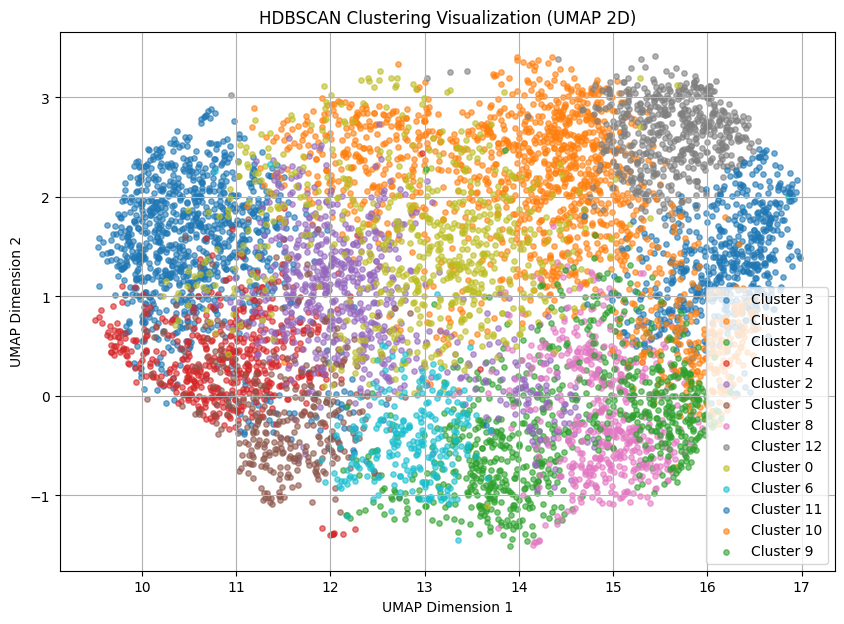

In [150]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

plt.figure(figsize=(10, 7))
unique_labels = df['hdbscan_cluster'].unique()

for label in unique_labels:
    mask = df['hdbscan_cluster'] == label
    plt.scatter(embedding_2d[mask, 0],
                embedding_2d[mask, 1],
                label=f"Cluster {label}" if label != -1 else "Noise (-1)",
                s=15, alpha=0.6)

plt.title("HDBSCAN Clustering Visualization (UMAP 2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.grid(True)
plt.show()


In [151]:
df_train

,title,artist,year,views,url,lyric,lyric_proccessed,tokens,agglo_cluster,kmeans_clustering,hdbscan_cluster
0,Untitled,Rex Orange County,2017,292064,https://genius.com/Rex-Orange-County-Untitled-...,So if for any reason there's some miscommunica...,so if for any reason there is some miscommunic...,"[reason, miscommunication, lying, face, immatu...",11,6,3
1,Dandelions,Ruth B.,2017,587288,https://genius.com/Ruth-B-Dandelions-lyrics,Maybe it's the way you say my name\nMaybe it's...,maybe it is the way you say my name\nmaybe it ...,"[maybe, way, say, name, maybe, way, play, game...",9,10,3
2,I Like,G Herbo,2017,204698,https://genius.com/G-Herbo-I-Like-lyrics,"Pull up in a new G-Wag'\nSky blue body paint, ...",pull up in a new gwag\nsky blue body paint soo...,"[pull, new, gwag, sky, blue, body, paint, soow...",11,7,1
3,Kiss Me,Ed Sheeran,2011,434377,https://genius.com/Ed-Sheeran-Kiss-Me-lyrics,"Yeah, I've been feelin' everything\nFrom hate ...",yeah i have been feelin everything\nfrom hate ...,"[yeah, feelin, everything, hate, love, love, l...",1,6,3
4,I Say A Little Prayer,Aretha Franklin,1968,401893,https://genius.com/Aretha-Franklin-I-Say-A-Lit...,(I say a little prayer for you)\nThe moment I ...,i say a little prayer for you\nthe moment i wa...,"[say, little, prayer, moment, wake, put, makeu...",9,6,3
...,...,...,...,...,...,...,...,...,...,...,...
7361,Ganja Burn,Nicki Minaj,2018,597004,https://genius.com/Nicki-Minaj-Ganja-Burn-lyrics,"Ayo, as the world turns, the blunt burns\nFash...",ayo as the world turns the blunt burns\nfashio...,"[ayo, world, turn, blunt, burn, fashion, icon,...",4,4,9
7362,I Kissed a Girl,Katy Perry,2008,748259,https://genius.com/Katy-Perry-I-Kissed-a-Girl-...,"I got so brave, drink in hand\nLost my discret...",i got so brave drink in hand\nlost my discreti...,"[got, brave, drink, hand, lost, discretion, us...",4,3,1
7363,One Shot 2 Shot,Eminem,2004,285353,https://genius.com/Eminem-One-Shot-2-Shot-lyrics,"One shot, two shot, three shots, four shots\nA...",one shot two shot three shots four shots\nall ...,"[one, shot, two, shot, three, shot, four, shot...",4,4,7
7364,Frontin,Pharrell Williams,2003,228883,https://genius.com/Pharrell-Williams-Frontin-l...,Don't wanna sound full of myself or rude\nBut ...,do not want to sound full of myself or rude\nb...,"[want, sound, full, rude, looking, dude, love,...",11,3,1


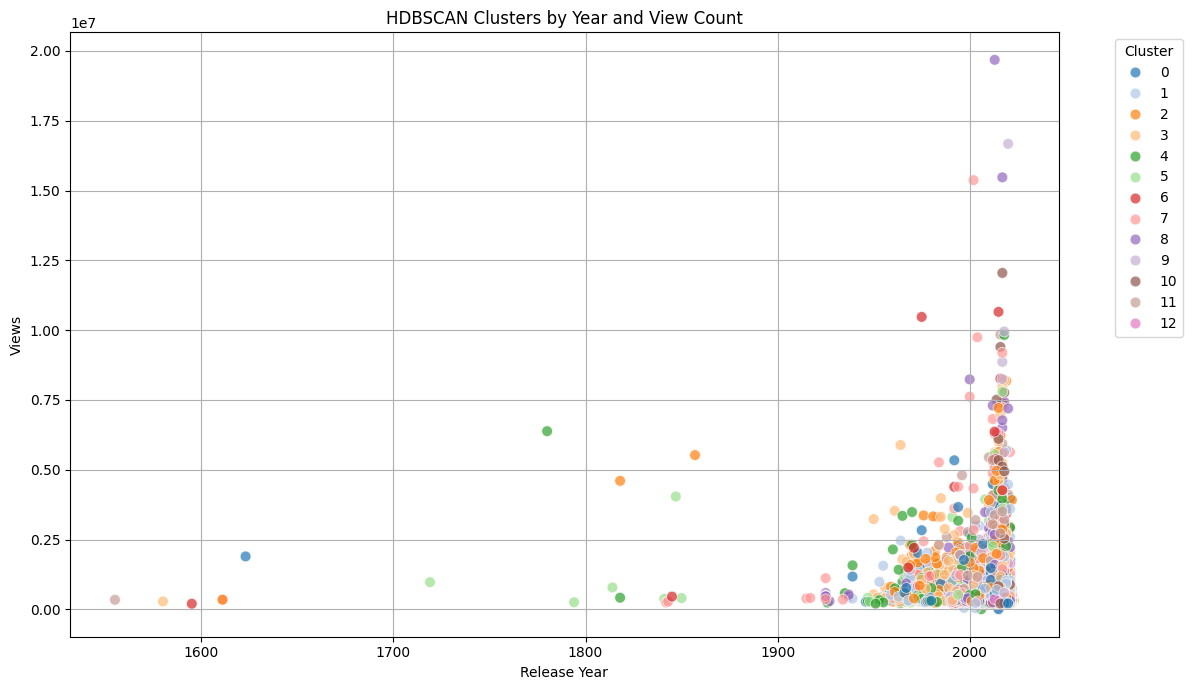

In [152]:
df_filtered = df_train[(df_train['year'] >= 1500) & (~df_train['year'].isna())]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered,
    x='year',
    y='views',
    hue='hdbscan_cluster',
    palette='tab20',
    alpha=0.7,
    s=60
)
plt.title("HDBSCAN Clusters by Year and View Count")
plt.xlabel("Release Year")
plt.ylabel("Views")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Testing Modelling

In [153]:
reduced_test = reducer.transform(embeddings_test)
distance_matrix_test = cosine_distances(reduced_test).astype(np.float64)

C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [154]:
clusterer_test = hdbscan.HDBSCAN(
    min_cluster_size=20,
    min_samples=5,
    metric='precomputed',
    cluster_selection_method='leaf'
)

raw_labels_test = clusterer_test.fit_predict(distance_matrix_test)
df_test['hdbscan_cluster'] = raw_labels_test

labels_test = raw_labels_test.copy()
mask_core = raw_labels_test != -1
mask_noise = raw_labels_test == -1

if np.any(mask_noise):
    nn = NearestNeighbors(n_neighbors=1, metric='cosine')
    nn.fit(reduced_test[mask_core])
    _, indices = nn.kneighbors(reduced_test[mask_noise])
    labels_test[mask_noise] = raw_labels_test[mask_core][indices[:, 0]]

df_test['hdbscan_cluster'] = labels_test

C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\moham\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


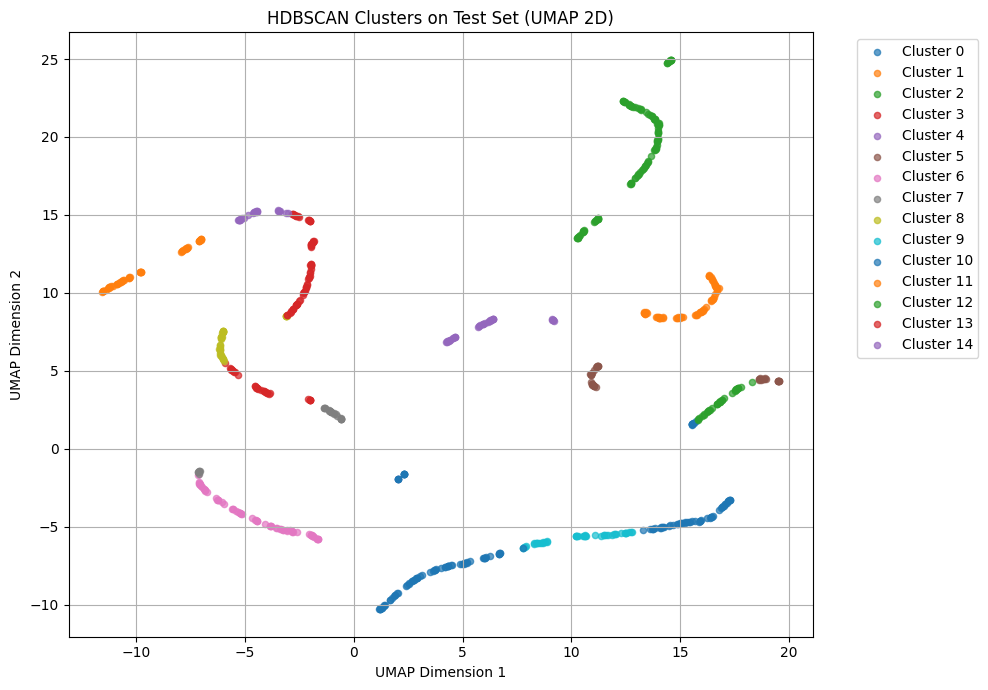

In [155]:
umap_2d = umap.UMAP(n_components=2, metric='cosine', random_state=42)
test_2d = umap_2d.fit_transform(reduced_test)

labels_test = df_test['hdbscan_cluster'].values
unique_labels = np.unique(labels_test)

plt.figure(figsize=(10, 7))
for label in unique_labels:
    mask = labels_test == label
    plt.scatter(test_2d[mask, 0], test_2d[mask, 1], s=20, alpha=0.7, label=f'Cluster {label}')

plt.title("HDBSCAN Clusters on Test Set (UMAP 2D)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

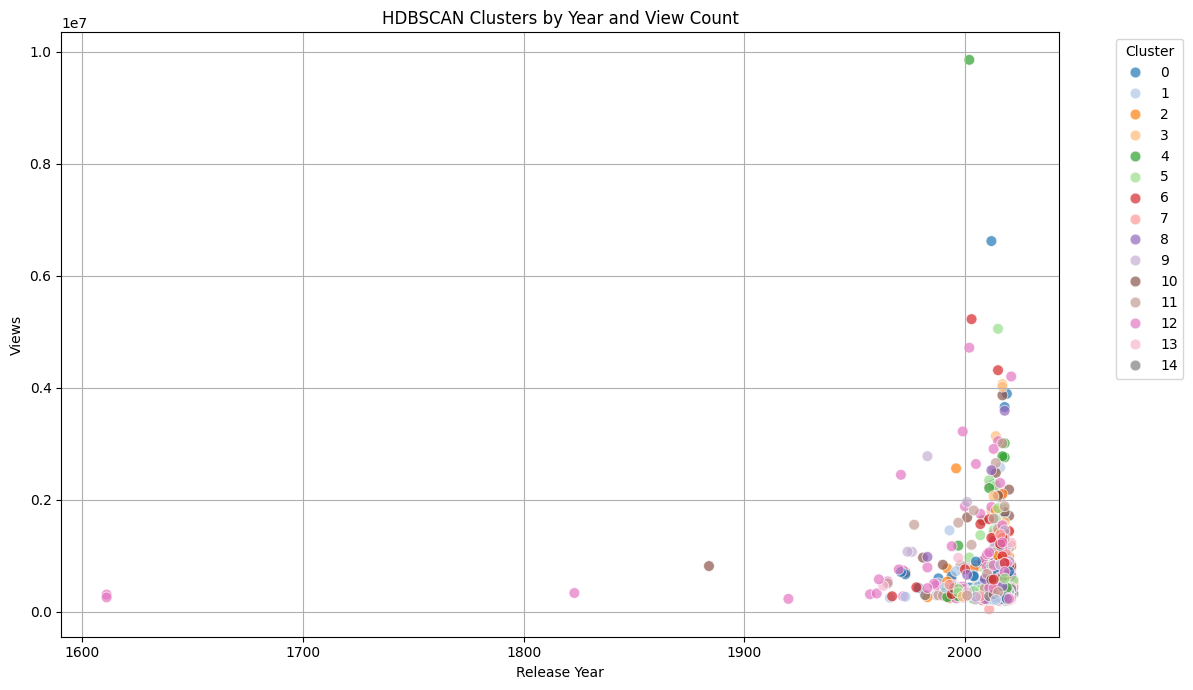

In [156]:
df_filtered_test = df_test[(df_test['year'] >= 1500) & (~df_test['year'].isna())]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df_filtered_test,
    x='year',
    y='views',
    hue='hdbscan_cluster',
    palette='tab20',
    alpha=0.7,
    s=60
)
plt.title("HDBSCAN Clusters by Year and View Count")
plt.xlabel("Release Year")
plt.ylabel("Views")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

## Clustering Result



In [157]:
df_train

,title,artist,year,views,url,lyric,lyric_proccessed,tokens,agglo_cluster,kmeans_clustering,hdbscan_cluster
0,Untitled,Rex Orange County,2017,292064,https://genius.com/Rex-Orange-County-Untitled-...,So if for any reason there's some miscommunica...,so if for any reason there is some miscommunic...,"[reason, miscommunication, lying, face, immatu...",11,6,3
1,Dandelions,Ruth B.,2017,587288,https://genius.com/Ruth-B-Dandelions-lyrics,Maybe it's the way you say my name\nMaybe it's...,maybe it is the way you say my name\nmaybe it ...,"[maybe, way, say, name, maybe, way, play, game...",9,10,3
2,I Like,G Herbo,2017,204698,https://genius.com/G-Herbo-I-Like-lyrics,"Pull up in a new G-Wag'\nSky blue body paint, ...",pull up in a new gwag\nsky blue body paint soo...,"[pull, new, gwag, sky, blue, body, paint, soow...",11,7,1
3,Kiss Me,Ed Sheeran,2011,434377,https://genius.com/Ed-Sheeran-Kiss-Me-lyrics,"Yeah, I've been feelin' everything\nFrom hate ...",yeah i have been feelin everything\nfrom hate ...,"[yeah, feelin, everything, hate, love, love, l...",1,6,3
4,I Say A Little Prayer,Aretha Franklin,1968,401893,https://genius.com/Aretha-Franklin-I-Say-A-Lit...,(I say a little prayer for you)\nThe moment I ...,i say a little prayer for you\nthe moment i wa...,"[say, little, prayer, moment, wake, put, makeu...",9,6,3
...,...,...,...,...,...,...,...,...,...,...,...
7361,Ganja Burn,Nicki Minaj,2018,597004,https://genius.com/Nicki-Minaj-Ganja-Burn-lyrics,"Ayo, as the world turns, the blunt burns\nFash...",ayo as the world turns the blunt burns\nfashio...,"[ayo, world, turn, blunt, burn, fashion, icon,...",4,4,9
7362,I Kissed a Girl,Katy Perry,2008,748259,https://genius.com/Katy-Perry-I-Kissed-a-Girl-...,"I got so brave, drink in hand\nLost my discret...",i got so brave drink in hand\nlost my discreti...,"[got, brave, drink, hand, lost, discretion, us...",4,3,1
7363,One Shot 2 Shot,Eminem,2004,285353,https://genius.com/Eminem-One-Shot-2-Shot-lyrics,"One shot, two shot, three shots, four shots\nA...",one shot two shot three shots four shots\nall ...,"[one, shot, two, shot, three, shot, four, shot...",4,4,7
7364,Frontin,Pharrell Williams,2003,228883,https://genius.com/Pharrell-Williams-Frontin-l...,Don't wanna sound full of myself or rude\nBut ...,do not want to sound full of myself or rude\nb...,"[want, sound, full, rude, looking, dude, love,...",11,3,1


In [158]:
df_test

,title,artist,year,views,url,lyric,lyric_proccessed,tokens,agglo_cluster,tsne_x,tsne_y,kmeans_clustering,hdbscan_cluster
0,BTS - Your eyes tell English Translation,Genius English Translations,2020,574010,https://genius.com/Genius-English-Translations...,"[Verse 1: Jung Kook,\nV\n]\nWhy are my eyes fi...",verse jung kook\nv\n\nwhy are my eyes filled ...,"[verse, jung, kook, eye, filled, tear, hey, st...",1,-1.522596,-10.227323,5,11
1,Superman,Eminem,2002,4716120,https://genius.com/Eminem-Superman-lyrics,Dina Rae\nThey call me Superman\nLeap tall hoe...,dina rae\nthey call me superman\nleap tall hoe...,"[dina, rae, call, superman, leap, tall, hoe, s...",1,6.644505,1.524600,7,12
2,Pussy Money Weed,Lil Wayne,2007,392937,https://genius.com/Lil-Wayne-Pussy-Money-Weed-...,"Oh, yes, I love her, like Egyptian\nShe's ""Poi...",oh yes i love her like egyptian\nshe is poison...,"[yes, love, like, egyptian, poison, michael, b...",1,-5.918290,-20.255148,0,1
3,Therefore I Am,Billie Eilish,2020,1712636,https://genius.com/Billie-Eilish-Therefore-I-A...,"I'm not your friend\nOr anything, damn\nYou th...",i am not your friend\nor anything damn\nyou th...,"[friend, anything, damn, think, man, think, th...",1,14.019512,-7.617885,3,10
4,Renegade,Big Red Machine,2021,404770,https://genius.com/Big-Red-Machine-Renegade-ly...,I tapped on your window on your darkest night\...,i tapped on your window on your darkest night\...,"[tapped, window, darkest, night, really, going...",7,11.029505,-11.486597,10,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,BTS - Outro: Tear English Translation,Genius English Translations,2018,712245,https://genius.com/Genius-English-Translations...,My heart that's stained with belated self-loat...,my heart that is stained with belated selfloat...,"[heart, stained, belated, selfloathing, someon...",1,8.355754,-4.524093,9,12
807,Every Season,Roddy Ricch,2018,592105,https://genius.com/Roddy-Ricch-Every-Season-ly...,"Beezo need cash only, you dig?\nThat boy Cassi...",beezo need cash only you dig\nthat boy cassius...,"[beezo, need, cash, dig, boy, cassius, married...",1,-6.361410,7.797288,7,5
808,Papercut,Linkin Park,2001,288929,https://genius.com/Linkin-Park-Papercut-lyrics,Why does it feel like night today?\nSomething ...,why does it feel like night today\nsomething i...,"[feel, like, night, today, something, right, t...",1,3.658518,-12.664087,3,11
809,Gas Pedal,Sage The Gemini,2013,573690,https://genius.com/Sage-The-Gemini-Gas-Pedal-l...,"Now speed up, gas pedal\nGas pedal (Gas pedal)...",now speed up gas pedal\ngas pedal gas pedal ga...,"[speed, gas, pedal, gas, pedal, gas, pedal, ga...",8,-9.621339,9.922438,8,6


In [159]:
train_cluster_result = df_train.copy()
train_cluster_result.head()

,title,artist,year,views,url,lyric,lyric_proccessed,tokens,agglo_cluster,kmeans_clustering,hdbscan_cluster
0,Untitled,Rex Orange County,2017,292064,https://genius.com/Rex-Orange-County-Untitled-...,So if for any reason there's some miscommunica...,so if for any reason there is some miscommunic...,"[reason, miscommunication, lying, face, immatu...",11,6,3
1,Dandelions,Ruth B.,2017,587288,https://genius.com/Ruth-B-Dandelions-lyrics,Maybe it's the way you say my name\nMaybe it's...,maybe it is the way you say my name\nmaybe it ...,"[maybe, way, say, name, maybe, way, play, game...",9,10,3
2,I Like,G Herbo,2017,204698,https://genius.com/G-Herbo-I-Like-lyrics,"Pull up in a new G-Wag'\nSky blue body paint, ...",pull up in a new gwag\nsky blue body paint soo...,"[pull, new, gwag, sky, blue, body, paint, soow...",11,7,1
3,Kiss Me,Ed Sheeran,2011,434377,https://genius.com/Ed-Sheeran-Kiss-Me-lyrics,"Yeah, I've been feelin' everything\nFrom hate ...",yeah i have been feelin everything\nfrom hate ...,"[yeah, feelin, everything, hate, love, love, l...",1,6,3
4,I Say A Little Prayer,Aretha Franklin,1968,401893,https://genius.com/Aretha-Franklin-I-Say-A-Lit...,(I say a little prayer for you)\nThe moment I ...,i say a little prayer for you\nthe moment i wa...,"[say, little, prayer, moment, wake, put, makeu...",9,6,3


In [160]:
test_cluster_result = df_test.drop(columns=["tsne_x", "tsne_y"])
test_cluster_result.head()

,title,artist,year,views,url,lyric,lyric_proccessed,tokens,agglo_cluster,kmeans_clustering,hdbscan_cluster
0,BTS - Your eyes tell English Translation,Genius English Translations,2020,574010,https://genius.com/Genius-English-Translations...,"[Verse 1: Jung Kook,\nV\n]\nWhy are my eyes fi...",verse jung kook\nv\n\nwhy are my eyes filled ...,"[verse, jung, kook, eye, filled, tear, hey, st...",1,5,11
1,Superman,Eminem,2002,4716120,https://genius.com/Eminem-Superman-lyrics,Dina Rae\nThey call me Superman\nLeap tall hoe...,dina rae\nthey call me superman\nleap tall hoe...,"[dina, rae, call, superman, leap, tall, hoe, s...",1,7,12
2,Pussy Money Weed,Lil Wayne,2007,392937,https://genius.com/Lil-Wayne-Pussy-Money-Weed-...,"Oh, yes, I love her, like Egyptian\nShe's ""Poi...",oh yes i love her like egyptian\nshe is poison...,"[yes, love, like, egyptian, poison, michael, b...",1,0,1
3,Therefore I Am,Billie Eilish,2020,1712636,https://genius.com/Billie-Eilish-Therefore-I-A...,"I'm not your friend\nOr anything, damn\nYou th...",i am not your friend\nor anything damn\nyou th...,"[friend, anything, damn, think, man, think, th...",1,3,10
4,Renegade,Big Red Machine,2021,404770,https://genius.com/Big-Red-Machine-Renegade-ly...,I tapped on your window on your darkest night\...,i tapped on your window on your darkest night\...,"[tapped, window, darkest, night, really, going...",7,10,5


In [161]:
train_cluster_result.to_csv("train_cluster_result.csv")
test_cluster_result.to_csv("test_cluster_result.csv")

# Exploratory Data Analysis



## Wordcloud

#### Train dataset

In [162]:
train_cluster_result.head()

,title,artist,year,views,url,lyric,lyric_proccessed,tokens,agglo_cluster,kmeans_clustering,hdbscan_cluster
0,Untitled,Rex Orange County,2017,292064,https://genius.com/Rex-Orange-County-Untitled-...,So if for any reason there's some miscommunica...,so if for any reason there is some miscommunic...,"[reason, miscommunication, lying, face, immatu...",11,6,3
1,Dandelions,Ruth B.,2017,587288,https://genius.com/Ruth-B-Dandelions-lyrics,Maybe it's the way you say my name\nMaybe it's...,maybe it is the way you say my name\nmaybe it ...,"[maybe, way, say, name, maybe, way, play, game...",9,10,3
2,I Like,G Herbo,2017,204698,https://genius.com/G-Herbo-I-Like-lyrics,"Pull up in a new G-Wag'\nSky blue body paint, ...",pull up in a new gwag\nsky blue body paint soo...,"[pull, new, gwag, sky, blue, body, paint, soow...",11,7,1
3,Kiss Me,Ed Sheeran,2011,434377,https://genius.com/Ed-Sheeran-Kiss-Me-lyrics,"Yeah, I've been feelin' everything\nFrom hate ...",yeah i have been feelin everything\nfrom hate ...,"[yeah, feelin, everything, hate, love, love, l...",1,6,3
4,I Say A Little Prayer,Aretha Franklin,1968,401893,https://genius.com/Aretha-Franklin-I-Say-A-Lit...,(I say a little prayer for you)\nThe moment I ...,i say a little prayer for you\nthe moment i wa...,"[say, little, prayer, moment, wake, put, makeu...",9,6,3


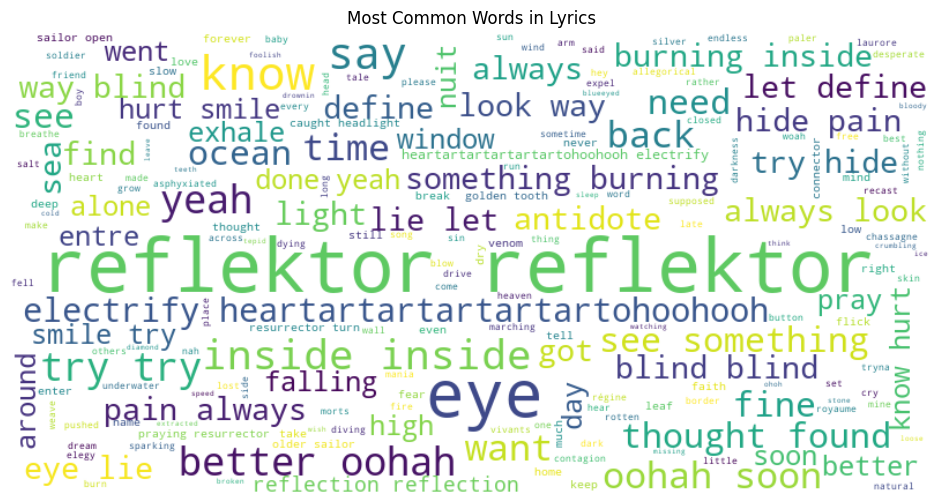

In [163]:
from wordcloud import WordCloud

cluster_curr = 2
df_cluster_n = train_cluster_result[train_cluster_result['agglo_cluster'] == cluster_curr]

all_words_clean = [word for tokens in df_cluster_n['tokens'] for word in tokens]
all_words_clean_str = " ".join(all_words_clean)

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_words_clean_str)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Lyrics")
plt.show()

In [164]:
from collections import Counter

word_counts_clean = Counter(all_words_clean)
word_counts_clean.most_common(20)

[('reflektor', 46),
 ('eye', 30),
 ('try', 19),
 ('get', 17),
 ('know', 16),
 ('inside', 15),
 ('always', 15),
 ('see', 12),
 ('yeah', 12),
 ('like', 12),
 ('oohah', 12),
 ('better', 12),
 ('soon', 11),
 ('electrify', 11),
 ('look', 10),
 ('say', 10),
 ('way', 10),
 ('blind', 10),
 ('define', 10),
 ('let', 9)]

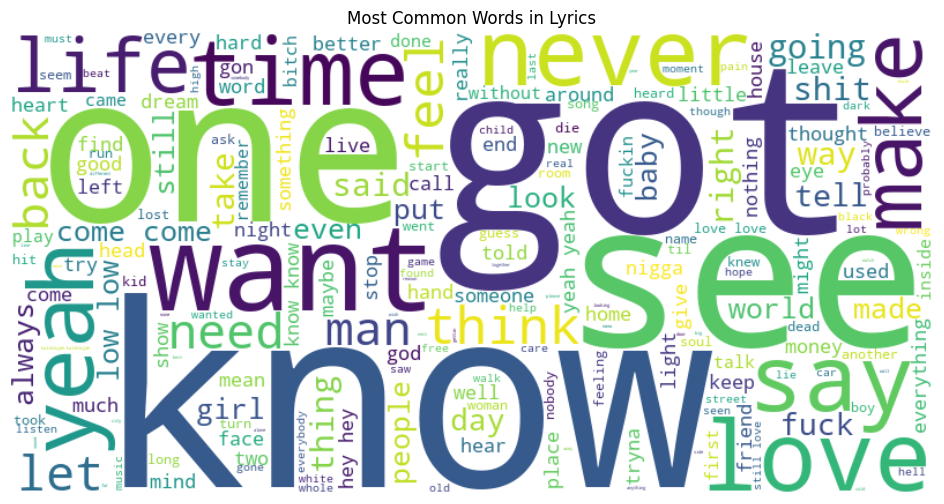

In [165]:
from wordcloud import WordCloud

cluster_curr = 2
df_cluster_n = train_cluster_result[train_cluster_result['kmeans_clustering'] == cluster_curr]

all_words_clean = [word for tokens in df_cluster_n['tokens'] for word in tokens]
all_words_clean_str = " ".join(all_words_clean)

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_words_clean_str)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Lyrics")
plt.show()

In [166]:
from collections import Counter

word_counts_clean = Counter(all_words_clean)
word_counts_clean.most_common(20)

[('like', 2770),
 ('know', 2338),
 ('got', 1733),
 ('love', 1634),
 ('want', 1603),
 ('get', 1391),
 ('yeah', 1347),
 ('time', 1146),
 ('one', 1135),
 ('never', 1116),
 ('would', 1113),
 ('say', 1069),
 ('come', 1047),
 ('see', 1024),
 ('let', 930),
 ('make', 870),
 ('life', 850),
 ('back', 848),
 ('feel', 847),
 ('could', 819)]

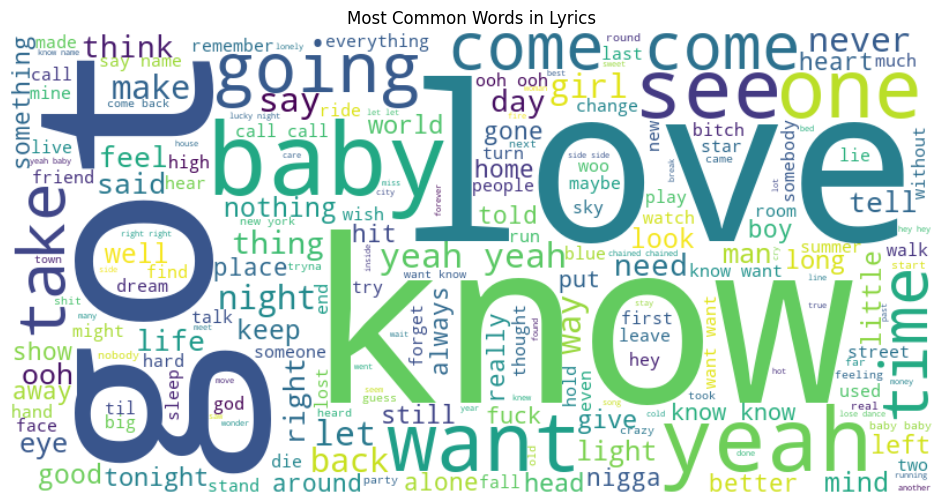

In [167]:
from wordcloud import WordCloud

cluster_curr = 2
df_cluster_n = train_cluster_result[train_cluster_result['hdbscan_cluster'] == cluster_curr]

all_words_clean = [word for tokens in df_cluster_n['tokens'] for word in tokens]
all_words_clean_str = " ".join(all_words_clean)

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_words_clean_str)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Lyrics")
plt.show()

In [168]:
from collections import Counter

word_counts_clean = Counter(all_words_clean)
word_counts_clean.most_common(20)

[('yeah', 1148),
 ('like', 1115),
 ('know', 1067),
 ('got', 893),
 ('want', 890),
 ('baby', 775),
 ('come', 731),
 ('love', 679),
 ('get', 666),
 ('girl', 549),
 ('one', 502),
 ('time', 484),
 ('night', 479),
 ('going', 474),
 ('let', 462),
 ('say', 446),
 ('never', 438),
 ('see', 431),
 ('back', 412),
 ('ooh', 392)]